
# HLT Project —   Cue linguistici + Error analysis

##  Objective

This notebook investigates **which linguistic signals humans and automatic models appear to associate with textual deception, and how these signals differ across decision makers**.

The analysis combines:

1. human self-reported linguistic cues;
2. spontaneous human strategies reported before cue prompting;
3. measurable linguistic properties of the review texts;
4. Qwen behavior and post-hoc cue analysis;
5. RoBERTa explainability and linguistic probing;
6. qualitative analysis of shared and system-specific errors.

The goal is not to claim that self-reported or post-hoc explanations reveal the true internal reasoning of a model. Instead, different sources of evidence are kept conceptually separate and compared cautiously.

All main prediction results were obtained before the analyses performed in this notebook.

## 1. Loadng the dataset

In [ ]:
from google.colab import drive
from pathlib import Path

import pandas as pd
import numpy as np


drive.mount("/content/drive")


PROJECT_DIR = Path(
    "/content/drive/MyDrive/HLT_project"
)

DATA_DIR = (
    PROJECT_DIR /
    "data" /
    "processed"
)

SAMPLES_DIR = (
    PROJECT_DIR /
    "samples"
)

RESULTS_DIR = (
    PROJECT_DIR /
    "results"
)


SAMPLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR = (
    PROJECT_DIR /
    "results"
)


FIGURES_DIR = (
    PROJECT_DIR /
    "figures"
)


HUMAN_DIR = (
    PROJECT_DIR /
    "human_experiment"
)


RAW_RESPONSES_DIR = (
    HUMAN_DIR /
    "raw_responses"
)


PROCESSED_HUMAN_DIR = (
    HUMAN_DIR /
    "processed"
)

df_clean = pd.read_csv(
    DATA_DIR /
    "positive_deceptive_reviews_clean.csv"
)


print(
    "Dataset shape:",
    df_clean.shape
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (800, 8)


In [ ]:
CLEAN_DATA_PATH = (
    DATA_DIR /
    "positive_deceptive_reviews_clean.csv"
)


HUMAN_JUDGMENTS_PATH = (
    PROCESSED_HUMAN_DIR /
    "human_judgments_long.csv"
)


HUMAN_MODEL_PATH = (
    PROCESSED_HUMAN_DIR /
    "human_model_comparison_120.csv"
)


QWEN_PATH = (
    RESULTS_DIR /
    "qwen_counterbalanced_full_results_final.csv"
)


ROBERTA_PATH = (
    RESULTS_DIR /
    "roberta_5fold_out_of_fold_predictions.csv"
)


files_to_check = {
    "Clean corpus":
        CLEAN_DATA_PATH,

    "Human judgments":
        HUMAN_JUDGMENTS_PATH,

    "Human-model comparison":
        HUMAN_MODEL_PATH,

    "Qwen predictions":
        QWEN_PATH,

    "RoBERTa predictions":
        ROBERTA_PATH
}


for name, path in files_to_check.items():

    print(
        name,
        "->",
        path.exists()
    )

Clean corpus -> True
Human judgments -> True
Human-model comparison -> True
Qwen predictions -> True
RoBERTa predictions -> True


## 2. Load Frozen Experimental Data

The datasets produced during the previous experimental stages are loaded from disk.

Human judgments and model predictions are not recomputed in this notebook.

In [ ]:
human_long_df = pd.read_csv(
    PROCESSED_HUMAN_DIR /
    "human_judgments_long.csv"
)


human_model_df = pd.read_csv(
    PROCESSED_HUMAN_DIR /
    "human_model_comparison_120.csv"
)


qwen_df = pd.read_csv(
    RESULTS_DIR /
    "qwen_counterbalanced_full_results_final.csv"
)


roberta_df = pd.read_csv(
    RESULTS_DIR /
    "roberta_5fold_out_of_fold_predictions.csv"
)


print(
    "Corpus reviews:",
    len(df_clean)
)


print(
    "Human judgments:",
    len(human_long_df)
)


print(
    "Human participants:",
    human_long_df[
        "participant_id"
    ].nunique()
)


print(
    "Human-study reviews:",
    len(human_model_df)
)


print(
    "Qwen predictions:",
    len(qwen_df)
)


print(
    "RoBERTa predictions:",
    len(roberta_df)
)

Corpus reviews: 800
Human judgments: 760
Human participants: 38
Human-study reviews: 120
Qwen predictions: 800
RoBERTa predictions: 800


## 3. Questionnaire Fields

The original Google Forms exports are used for the cue analysis so that open-ended responses and checklist selections are preserved exactly as submitted.

Participant inclusion is not recomputed. Only participants already retained as valid in the Day 5 analysis are included.

In [ ]:
OPEN_STRATEGY_QUESTION = (
    "Before looking at the list of characteristics below, "
    "briefly describe any characteristics, patterns, or strategies "
    "that influenced your judgments. "
    'If you did not use any particular strategy, write "None".'
)


TRUTHFUL_CUE_QUESTION = (
    "Which of the following characteristics generally made a review "
    "seem more likely to be TRUTHFUL to you? Select all that apply."
)


DECEPTIVE_CUE_QUESTION = (
    "Which of the following characteristics generally made a review "
    "seem more likely to be DECEPTIVE to you? Select all that apply."
)


ENGLISH_QUESTION = (
    "How would you rate your English proficiency?"
)


REVIEW_FAMILIARITY_QUESTION = (
    "How often do you read online reviews when choosing products, "
    "hotels, restaurants, or services?"
)

In [ ]:
def find_single_question_column(
    dataframe,
    question_text
):

    matching_columns = []


    for column in dataframe.columns:

        if str(column).startswith(
            question_text
        ):

            matching_columns.append(
                column
            )


    if len(matching_columns) != 1:

        raise ValueError(
            f"Expected one column for:\n"
            f"{question_text}\n"
            f"Found: {len(matching_columns)}"
        )


    return matching_columns[0]

## 4. Load Original Questionnaire Responses

The original questionnaire responses are loaded from the six Google Forms exports.

Participant IDs are reconstructed using the same block-and-row convention adopted during Day 5. The resulting data are then restricted to the participants already validated in the human-performance analysis.

In [ ]:
valid_participants = set(
    human_long_df[
        "participant_id"
    ].unique()
)


questionnaire_rows = []


for block_number in range(
    1,
    7
):

    block_name = (
        f"B{block_number}"
    )


    response_path = (
        RAW_RESPONSES_DIR /
        f"human_{block_name}_responses.csv"
    )


    response_df = pd.read_csv(
        response_path
    )


    open_column = (
        find_single_question_column(
            response_df,
            OPEN_STRATEGY_QUESTION
        )
    )


    truthful_column = (
        find_single_question_column(
            response_df,
            TRUTHFUL_CUE_QUESTION
        )
    )


    deceptive_column = (
        find_single_question_column(
            response_df,
            DECEPTIVE_CUE_QUESTION
        )
    )


    english_column = (
        find_single_question_column(
            response_df,
            ENGLISH_QUESTION
        )
    )


    familiarity_column = (
        find_single_question_column(
            response_df,
            REVIEW_FAMILIARITY_QUESTION
        )
    )


    for response_index, row in (
        response_df.iterrows()
    ):

        participant_id = (
            f"{block_name}_"
            f"P{response_index + 1:03d}"
        )


        if participant_id not in valid_participants:

            continue


        questionnaire_rows.append({

            "participant_id":
                participant_id,

            "block":
                block_name,

            "open_strategy":
                row[
                    open_column
                ],

            "truthful_cues_raw":
                row[
                    truthful_column
                ],

            "deceptive_cues_raw":
                row[
                    deceptive_column
                ],

            "english_proficiency":
                row[
                    english_column
                ],

            "review_familiarity":
                row[
                    familiarity_column
                ]
        })


participant_questionnaire_df = (
    pd.DataFrame(
        questionnaire_rows
    )
)


print(
    "Questionnaire participants:",
    len(
        participant_questionnaire_df
    )
)


print(
    "Unique participant IDs:",
    participant_questionnaire_df[
        "participant_id"
    ].nunique()
)

Questionnaire participants: 38
Unique participant IDs: 38


In [ ]:
questionnaire_ids = set(
    participant_questionnaire_df[
        "participant_id"
    ]
)


print(
    "Same participants as Day 5:",
    questionnaire_ids
    ==
    valid_participants
)


print(
    "Missing participants:",
    valid_participants
    -
    questionnaire_ids
)


print(
    "Unexpected participants:",
    questionnaire_ids
    -
    valid_participants
)

Same participants as Day 5: True
Missing participants: set()
Unexpected participants: set()


## 5. Define the Pre-Specified Cue Taxonomy

The checklist categories were defined before data collection and are therefore treated as the primary quantitative taxonomy for human self-reported cues.

In [ ]:
CUE_TAXONOMY = [

    "Level of specific detail",

    "References to specific places, times, or situations",

    "Presence of both positive and negative aspects",

    "Emotional intensity",

    "Persuasiveness / quality of the arguments",

    "Length of the review",

    "Grammar and spelling",

    "Use of first-person or personal language",

    "Exaggerated, promotional, or flattering language",

    "Complexity / readability of the writing",

    "Repetition of words, ideas, or expressions",

    "Use of punctuation or emphasis "
    "(e.g., exclamation marks, capital letters)"
]


NONE_CUE = (
    "None of these / I did not use a consistent characteristic"
)

In [ ]:
def parse_cue_response(
    response
):

    if pd.isna(
        response
    ):

        return [], False


    response = str(
        response
    )


    selected_cues = []


    for cue in CUE_TAXONOMY:

        if cue in response:

            selected_cues.append(
                cue
            )


    selected_none = (
        NONE_CUE in response
    )


    return (
        selected_cues,
        selected_none
    )

In [ ]:
participant_questionnaire_df[
    "truthful_cues"
] = (
    participant_questionnaire_df[
        "truthful_cues_raw"
    ]
    .apply(
        lambda x:
        parse_cue_response(x)[0]
    )
)


participant_questionnaire_df[
    "truthful_none"
] = (
    participant_questionnaire_df[
        "truthful_cues_raw"
    ]
    .apply(
        lambda x:
        parse_cue_response(x)[1]
    )
)


participant_questionnaire_df[
    "deceptive_cues"
] = (
    participant_questionnaire_df[
        "deceptive_cues_raw"
    ]
    .apply(
        lambda x:
        parse_cue_response(x)[0]
    )
)


participant_questionnaire_df[
    "deceptive_none"
] = (
    participant_questionnaire_df[
        "deceptive_cues_raw"
    ]
    .apply(
        lambda x:
        parse_cue_response(x)[1]
    )
)

## 6. Check Checklist Consistency

Selecting both "None of these" and one or more substantive cues is treated as an internally inconsistent checklist response.

Such cases are excluded only from the corresponding cue-direction analysis. The participant and their classification judgments remain valid.

In [ ]:
participant_questionnaire_df[
    "truthful_consistent"
] = ~(
    participant_questionnaire_df[
        "truthful_none"
    ]
    &
    participant_questionnaire_df[
        "truthful_cues"
    ].apply(
        len
    ).gt(0)
)


participant_questionnaire_df[
    "deceptive_consistent"
] = ~(
    participant_questionnaire_df[
        "deceptive_none"
    ]
    &
    participant_questionnaire_df[
        "deceptive_cues"
    ].apply(
        len
    ).gt(0)
)


print(
    "Inconsistent truthful checklist responses:",
    (
        ~participant_questionnaire_df[
            "truthful_consistent"
        ]
    ).sum()
)


print(
    "Inconsistent deceptive checklist responses:",
    (
        ~participant_questionnaire_df[
            "deceptive_consistent"
        ]
    ).sum()
)

Inconsistent truthful checklist responses: 1
Inconsistent deceptive checklist responses: 0


## 7. Build the Human Cue Dataset

Each valid checklist response is converted into participant-by-cue observations separately for truthful and deceptive judgments.

In [ ]:
cue_rows = []


for _, row in (
    participant_questionnaire_df.iterrows()
):

    if row[
        "truthful_consistent"
    ]:

        for cue in CUE_TAXONOMY:

            cue_rows.append({

                "participant_id":
                    row[
                        "participant_id"
                    ],

                "direction":
                    "truthful",

                "cue":
                    cue,

                "selected":
                    cue in row[
                        "truthful_cues"
                    ]
            })


    if row[
        "deceptive_consistent"
    ]:

        for cue in CUE_TAXONOMY:

            cue_rows.append({

                "participant_id":
                    row[
                        "participant_id"
                    ],

                "direction":
                    "deceptive",

                "cue":
                    cue,

                "selected":
                    cue in row[
                        "deceptive_cues"
                    ]
            })


cue_long_df = pd.DataFrame(
    cue_rows
)


print(
    "Cue-level rows:",
    len(cue_long_df)
)


display(
    cue_long_df.head()
)

Cue-level rows: 900


,participant_id,direction,cue,selected
0,B1_P001,truthful,Level of specific detail,False
1,B1_P001,truthful,"References to specific places, times, or situa...",False
2,B1_P001,truthful,Presence of both positive and negative aspects,True
3,B1_P001,truthful,Emotional intensity,True
4,B1_P001,truthful,Persuasiveness / quality of the arguments,False


## 8. Human Self-Reported Cue Frequencies

For each cue, the proportion of participants selecting it is calculated separately for characteristics associated with truthful and deceptive reviews.

The analysis is descriptive. No separate significance test is performed for each cue.

In [ ]:
cue_frequency_df = (
    cue_long_df
    .groupby(
        [
            "direction",
            "cue"
        ]
    )
    .agg(

        n_participants=(
            "participant_id",
            "nunique"
        ),

        n_selected=(
            "selected",
            "sum"
        ),

        proportion_selected=(
            "selected",
            "mean"
        )
    )
    .reset_index()
)


display(
    cue_frequency_df
    .sort_values(
        [
            "direction",
            "proportion_selected"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(3)
)

,direction,cue,n_participants,n_selected,proportion_selected
2,deceptive,"Exaggerated, promotional, or flattering language",38,28,0.737
3,deceptive,Grammar and spelling,38,19,0.500
5,deceptive,Level of specific detail,38,17,0.447
0,deceptive,Complexity / readability of the writing,38,16,0.421
9,deceptive,"Repetition of words, ideas, or expressions",38,16,0.421
4,deceptive,Length of the review,38,15,0.395
6,deceptive,Persuasiveness / quality of the arguments,38,15,0.395
11,deceptive,"Use of punctuation or emphasis (e.g., exclamat...",38,10,0.263
1,deceptive,Emotional intensity,38,6,0.158
8,deceptive,"References to specific places, times, or situa...",38,5,0.132


In [ ]:
cue_direction_df = (
    cue_frequency_df
    .pivot(
        index="cue",
        columns="direction",
        values="proportion_selected"
    )
    .reset_index()
)


cue_direction_df[
    "direction_difference"
] = (
    cue_direction_df[
        "truthful"
    ]
    -
    cue_direction_df[
        "deceptive"
    ]
)


cue_direction_df = (
    cue_direction_df
    .sort_values(
        "direction_difference",
        ascending=False
    )
)


display(
    cue_direction_df.round(3)
)

direction,cue,deceptive,truthful,direction_difference
7,Presence of both positive and negative aspects,0.053,0.649,0.596
8,"References to specific places, times, or situa...",0.132,0.486,0.355
1,Emotional intensity,0.158,0.378,0.220
10,Use of first-person or personal language,0.105,0.270,0.165
11,"Use of punctuation or emphasis (e.g., exclamat...",0.263,0.378,0.115
3,Grammar and spelling,0.500,0.595,0.095
5,Level of specific detail,0.447,0.459,0.012
9,"Repetition of words, ideas, or expressions",0.421,0.324,-0.097
4,Length of the review,0.395,0.216,-0.179
0,Complexity / readability of the writing,0.421,0.216,-0.205


### Human Self-Reported Cue Patterns

Human self-reports revealed several strongly directional linguistic cues.

The clearest cue associated with perceived truthfulness was the presence of both positive and negative aspects. This characteristic was selected by 64.9% of participants in the truthful checklist but only 5.3% in the deceptive checklist.

References to specific places, times, or situations were also more strongly associated with truthfulness (48.6% vs. 13.2%).

Conversely, exaggerated, promotional, or flattering language showed the strongest association with perceived deception. It was selected by 73.7% of participants as a deceptive cue but only 8.1% as a truthful cue.

Persuasiveness, writing complexity, and review length were also more frequently associated with deception.

Not all cues showed a consistent direction. Most notably, the level of specific detail was selected at almost identical rates for truthful and deceptive judgments (45.9% vs. 44.7%). Grammar and spelling also showed relatively little directional separation.

This suggests that some characteristics functioned as general judgment criteria whose interpretation depended on how they appeared in a particular review, rather than as cues with a fixed truthful or deceptive meaning.

These results represent participants' self-reported strategies and should not be interpreted as direct evidence that these cues causally determined their individual classifications.

## 9. Visualize Human Self-Reported Cue Directions

The proportions of participants associating each cue with truthful and deceptive reviews are compared directly.

Cues are ordered according to the difference between truthful and deceptive selection rates.

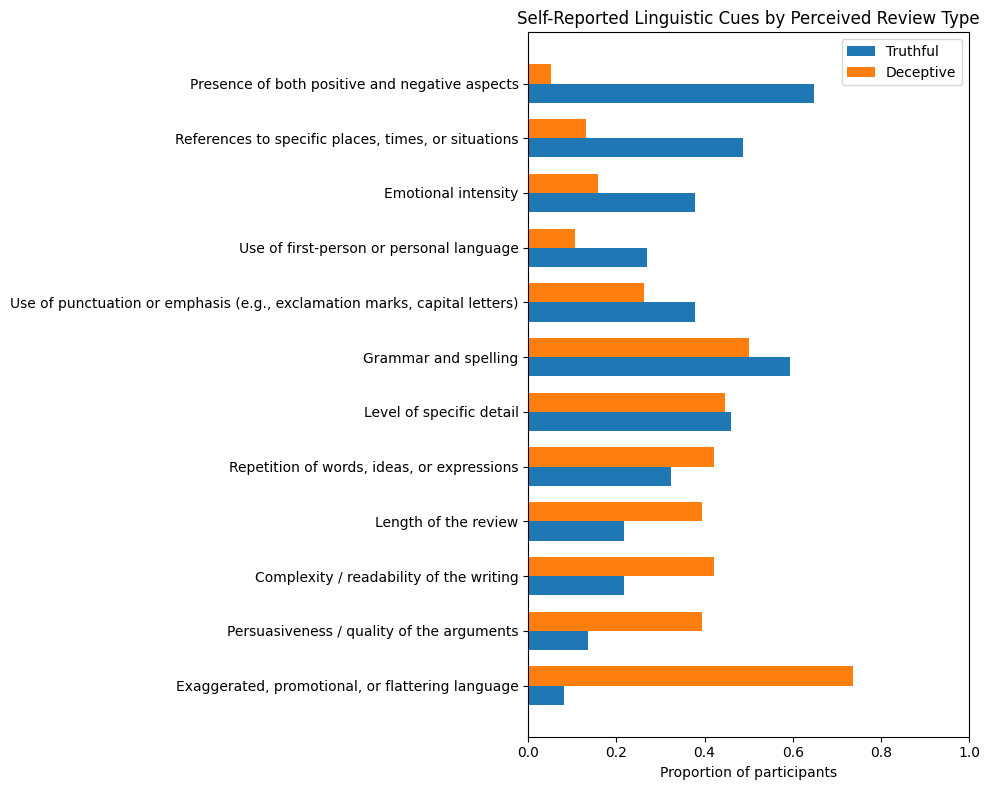

In [ ]:
import matplotlib.pyplot as plt

plot_df = (
    cue_direction_df
    .sort_values(
        "direction_difference"
    )
    .reset_index(
        drop=True
    )
)


y = np.arange(
    len(
        plot_df
    )
)


height = 0.35


fig, ax = plt.subplots(
    figsize=(10, 8)
)


ax.barh(
    y - height / 2,
    plot_df[
        "truthful"
    ],
    height,
    label="Truthful"
)


ax.barh(
    y + height / 2,
    plot_df[
        "deceptive"
    ],
    height,
    label="Deceptive"
)


ax.set_yticks(
    y
)


ax.set_yticklabels(
    plot_df[
        "cue"
    ]
)


ax.set_xlim(
    0,
    1
)


ax.set_xlabel(
    "Proportion of participants"
)


ax.set_title(
    "Self-Reported Linguistic Cues by Perceived Review Type"
)


ax.legend()


fig.tight_layout()


fig.savefig(
    FIGURES_DIR /
    "human_self_reported_cues.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## 10. Inspect Spontaneous Human Strategies

Before coding the open-ended responses, the original answers are inspected without reference to participant accuracy or model behavior.

The coding procedure will use a small predefined codebook based primarily on the cue taxonomy established before data collection, while allowing genuinely new strategies to be recorded as emergent categories.

In [ ]:
open_strategy_df = (
    participant_questionnaire_df[
        [
            "participant_id",
            "block",
            "open_strategy"
        ]
    ]
    .copy()
)


print(
    "Open-ended responses:",
    len(
        open_strategy_df
    )
)


print(
    "Missing responses:",
    open_strategy_df[
        "open_strategy"
    ].isna().sum()
)


display(
    open_strategy_df
)

Open-ended responses: 38
Missing responses: 10


,participant_id,block,open_strategy
0,B1_P001,B1,In base a quelle che mi sembravano più umane e...
1,B1_P002,B1,nothing
2,B1_P003,B1,NaN
3,B1_P004,B1,"If there is not much info about the room, food..."
4,B1_P005,B1,sometimes there were some mistakes in the phra...
5,B2_P001,B2,NaN
6,B2_P002,B2,"Spelling errors, level of details, prices"
7,B2_P003,B2,"Complex words, typos, grammatical errors, punc..."
8,B2_P004,B2,NaN
9,B2_P005,B2,"In some reviews there were misspelled words, w..."


## 11. Inspect Complete Open-Ended Responses

Open-ended responses are examined in their original form before qualitative coding.

Missing responses are distinguished from explicit statements indicating that no particular strategy was used.

In [ ]:
for _, row in open_strategy_df.iterrows():

    print(
        "=" * 80
    )

    print(
        row["participant_id"]
    )

    print(
        row["open_strategy"]
    )

    print()

B1_P001
In base a quelle che mi sembravano più umane e anche a come le scriverei io se ci fossi veramente stata o meno 

B1_P002
nothing

B1_P003
nan

B1_P004
If there is not much info about the room, food, locations it is suspicious. Same goes for perfectly written text (ai generated for example).

B1_P005
sometimes there were some mistakes in the phrase, so the review seemed to me a bit deceptive. 

B2_P001
nan

B2_P002
Spelling errors, level of details, prices

B2_P003
Complex words, typos, grammatical errors, punctuation

B2_P004
nan

B2_P005
In some reviews there were misspelled words, while in some others there were too many details

B2_P006
nan

B2_P007
My judments are based on the length of the sentences, generally the IA based are shorter, and also on the frequency of punctuation marks, also the very specific language, in my opinion, is more related to an IA use. 

B2_P008
The hotel’s price and the specific details

B2_P009
None 

B2_P010
Details

B3_P001
if answers seemed mor

In [ ]:
open_strategy_df[
    "missing_response"
] = (
    open_strategy_df[
        "open_strategy"
    ].isna()
)


open_strategy_df[
    "explicit_no_strategy"
] = (
    open_strategy_df[
        "open_strategy"
    ]
    .fillna("")
    .str.strip()
    .str.lower()
    .isin(
        [
            "none",
            "nothing"
        ]
    )
)


print(
    "Total participants:",
    len(open_strategy_df)
)


print(
    "Missing open-ended responses:",
    open_strategy_df[
        "missing_response"
    ].sum()
)


print(
    "Explicit no-strategy responses:",
    open_strategy_df[
        "explicit_no_strategy"
    ].sum()
)


print(
    "Substantive open-ended responses:",
    (
        ~open_strategy_df[
            "missing_response"
        ]
        &
        ~open_strategy_df[
            "explicit_no_strategy"
        ]
    ).sum()
)

Total participants: 38
Missing open-ended responses: 10
Explicit no-strategy responses: 3
Substantive open-ended responses: 25


## 12. Open-Ended Strategy Coding Protocol

Open-ended responses were provided before participants were exposed to the predefined cue checklist.

The responses are coded manually using a small multi-label codebook. The twelve predefined checklist categories form the core of the codebook, while a limited number of genuinely distinct strategies emerging from the open-ended responses are added as emergent categories.

Coding is performed without using participant accuracy, gold labels, or model predictions.

A single response may receive multiple codes.

When a participant explicitly indicates whether a characteristic suggests truthfulness or deception, that direction is coded separately as:

- `truthful`
- `deceptive`
- `unspecified`

The same cue may receive both directions for the same participant when the response explicitly indicates that its interpretation depends on context.

Missing responses are not treated as absence of a strategy. Explicit responses such as "None" or "nothing" are recorded separately as `NO_STRATEGY`.

In [ ]:
substantive_open_df = (
    open_strategy_df[
        ~open_strategy_df[
            "missing_response"
        ]
        &
        ~open_strategy_df[
            "explicit_no_strategy"
        ]
    ]
    .copy()
)


coding_template_df = (
    substantive_open_df[
        [
            "participant_id",
            "block",
            "open_strategy"
        ]
    ]
    .reset_index(
        drop=True
    )
)


print(
    "Responses to code:",
    len(
        coding_template_df
    )
)


display(
    coding_template_df
)

Responses to code: 25


,participant_id,block,open_strategy
0,B1_P001,B1,In base a quelle che mi sembravano più umane e...
1,B1_P004,B1,"If there is not much info about the room, food..."
2,B1_P005,B1,sometimes there were some mistakes in the phra...
3,B2_P002,B2,"Spelling errors, level of details, prices"
4,B2_P003,B2,"Complex words, typos, grammatical errors, punc..."
5,B2_P005,B2,"In some reviews there were misspelled words, w..."
6,B2_P007,B2,My judments are based on the length of the sen...
7,B2_P008,B2,The hotel’s price and the specific details
8,B2_P010,B2,Details
9,B3_P001,B3,if answers seemed more spontaneous to me


## 13. Open-Ended Response Codebook

Open-ended responses were provided before participants were exposed to the predefined cue checklist.

Responses are manually coded using a multi-label codebook. The twelve predefined checklist categories form the core of the codebook. Three additional categories are included because they capture clearly distinct strategies that emerged in the open-ended responses.

A response may receive multiple codes.

When the participant explicitly indicates whether a cue suggests truthfulness or deception, its direction is coded as `truthful` or `deceptive`. If no direction is explicitly stated, it is coded as `unspecified`.

Missing responses are not treated as absence of a strategy. Explicit responses such as "None" or "nothing" are recorded separately as `NO_STRATEGY`.

### Predefined codes

- `SPECIFIC_DETAIL`: amount, precision, or usefulness of descriptive detail
- `SITUATIONAL_SPECIFICITY`: concrete places, times, prices, events, or situations
- `MIXED_EVALUATION`: presence of both positive and negative aspects
- `EMOTIONAL_INTENSITY`: strength or excess of emotional expression
- `PERSUASIVENESS`: attempt to convince or influence the reader
- `LENGTH`: length of the review or its sentences
- `GRAMMAR_SPELLING`: grammar, spelling, or typographical correctness
- `PERSONAL_LANGUAGE`: explicit personal perspective or first-person experience
- `PROMOTIONAL_LANGUAGE`: exaggerated, flattering, or advertisement-like language
- `COMPLEXITY_READABILITY`: complexity, simplicity, or fluency of writing
- `REPETITION`: repetition of words, phrases, or structural patterns
- `PUNCTUATION_EMPHASIS`: punctuation, capitalization, spacing, or emphasis

### Emergent codes

- `NATURALNESS_SPONTANEITY`: whether the text appears human, natural, spontaneous, or genuinely written
- `PLAUSIBILITY_REALISM`: whether the described experience appears believable or realistic
- `AI_HEURISTIC`: explicit attempt to identify AI-generated or AI-like writing
- `VOCABULARY_LEXICAL_CHOICE`: explicit attention to the type, richness, recurrence, or choice of words and expressions, when this is not specifically a matter of grammatical correctness or general readability.
- `STYLE_COHERENCE`: explicit evaluation of whether the writing exhibits a coherent, recognizable, or plausible style for the apparent reviewer.

These categories are kept separate from `COMPLEXITY_READABILITY` and `NATURALNESS_SPONTANEITY` because participants may explicitly evaluate lexical choice or stylistic coherence without referring to text complexity or overall human-like naturalness.

`OTHER` is reserved for meaningful strategies that cannot be represented by any of the above categories.

In [ ]:
manual_codes = []


def add_code(
    participant_id,
    code,
    direction,
    cue_form
):

    manual_codes.append({

        "participant_id":
            participant_id,

        "code":
            code,

        "direction":
            direction,

        "cue_form":
            cue_form
    })

In [ ]:

# B1

add_code(
    "B1_P001",
    "NATURALNESS_SPONTANEITY",
    "truthful",
    "review seems more human"
)

add_code(
    "B1_P001",
    "PLAUSIBILITY_REALISM",
    "truthful",
    "review resembles how the participant would write after a real stay"
)


add_code(
    "B1_P004",
    "SPECIFIC_DETAIL",
    "deceptive",
    "too little information about the room, food, or location"
)

add_code(
    "B1_P004",
    "GRAMMAR_SPELLING",
    "deceptive",
    "text appears too perfectly written"
)

add_code(
    "B1_P004",
    "AI_HEURISTIC",
    "deceptive",
    "perfectly written text is associated with AI generation"
)


add_code(
    "B1_P005",
    "GRAMMAR_SPELLING",
    "deceptive",
    "mistakes in phrasing"
)


# B2

add_code(
    "B2_P002",
    "GRAMMAR_SPELLING",
    "unspecified",
    "spelling errors"
)

add_code(
    "B2_P002",
    "SPECIFIC_DETAIL",
    "unspecified",
    "level of detail"
)

add_code(
    "B2_P002",
    "SITUATIONAL_SPECIFICITY",
    "unspecified",
    "prices"
)


add_code(
    "B2_P003",
    "COMPLEXITY_READABILITY",
    "unspecified",
    "complex words"
)

add_code(
    "B2_P003",
    "GRAMMAR_SPELLING",
    "unspecified",
    "typos and grammatical errors"
)

add_code(
    "B2_P003",
    "PUNCTUATION_EMPHASIS",
    "unspecified",
    "punctuation"
)


add_code(
    "B2_P005",
    "GRAMMAR_SPELLING",
    "unspecified",
    "misspelled words"
)

add_code(
    "B2_P005",
    "SPECIFIC_DETAIL",
    "unspecified",
    "too many details"
)


add_code(
    "B2_P007",
    "LENGTH",
    "deceptive",
    "AI-based reviews or sentences are generally shorter"
)

add_code(
    "B2_P007",
    "VOCABULARY_LEXICAL_CHOICE",
    "deceptive",
    "very specific language is associated with AI use"
)

add_code(
    "B2_P007",
    "PUNCTUATION_EMPHASIS",
    "deceptive",
    "frequency of punctuation marks is used as an indicator of AI use"
)

add_code(
    "B2_P007",
    "AI_HEURISTIC",
    "deceptive",
    "review characteristics are explicitly evaluated as signs of AI use"
)


add_code(
    "B2_P008",
    "SITUATIONAL_SPECIFICITY",
    "unspecified",
    "hotel price"
)

add_code(
    "B2_P008",
    "SPECIFIC_DETAIL",
    "unspecified",
    "specific details"
)


add_code(
    "B2_P010",
    "SPECIFIC_DETAIL",
    "unspecified",
    "details"
)


# B3

add_code(
    "B3_P001",
    "NATURALNESS_SPONTANEITY",
    "truthful",
    "answers seem more spontaneous"
)


add_code(
    "B3_P002",
    "GRAMMAR_SPELLING",
    "unspecified",
    "grammar"
)


add_code(
    "B3_P005",
    "PUNCTUATION_EMPHASIS",
    "deceptive",
    "unusual punctuation such as repeated dashes"
)

add_code(
    "B3_P005",
    "VOCABULARY_LEXICAL_CHOICE",
    "deceptive",
    "use of overly specific adjectives"
)

add_code(
    "B3_P005",
    "AI_HEURISTIC",
    "deceptive",
    "punctuation and overly specific adjectives are associated with AI writing"
)

add_code(
    "B3_P005",
    "STYLE_COHERENCE",
    "deceptive",
    "slang appears inconsistent with the apparent age or character of the reviewer"
)

add_code(
    "B3_P005",
    "NATURALNESS_SPONTANEITY",
    "deceptive",
    "slang appears deliberately inserted to make the review seem more authentic"
)

add_code(
    "B3_P005",
    "LENGTH",
    "truthful",
    "short reviews seem natural"
)

add_code(
    "B3_P005",
    "OTHER",
    "deceptive",
    "description of what can be done at the hotel resembles a travel guide rather than a review"
)


# B4

add_code(
    "B4_P001",
    "SPECIFIC_DETAIL",
    "deceptive",
    "very detailed descriptions that only highlight positive aspects"
)

add_code(
    "B4_P001",
    "SITUATIONAL_SPECIFICITY",
    "truthful",
    "description extends beyond generic hotel characteristics"
)

add_code(
    "B4_P001",
    "MIXED_EVALUATION",
    "truthful",
    "presence of both negative and positive aspects"
)

add_code(
    "B4_P001",
    "PERSUASIVENESS",
    "deceptive",
    "comparisons with alternatives favor the reviewed hotel"
)

add_code(
    "B4_P001",
    "PLAUSIBILITY_REALISM",
    "truthful",
    "comments about service and staff seem realistic"
)


add_code(
    "B4_P002",
    "SPECIFIC_DETAIL",
    "unspecified",
    "level of detail used in the descriptions"
)


# B5

add_code(
    "B5_P001",
    "SPECIFIC_DETAIL",
    "unspecified",
    "descriptions of bedrooms and hotels"
)

add_code(
    "B5_P001",
    "OTHER",
    "unspecified",
    "compliments to staff and comparisons with other hotels"
)

add_code(
    "B5_P002",
    "NATURALNESS_SPONTANEITY",
    "truthful",
    "text seems genuinely written by a person who wanted to review the hotel"
)

add_code(
    "B5_P002",
    "PROMOTIONAL_LANGUAGE",
    "deceptive",
    "advertising-like language and unnecessary embellishment"
)

add_code(
    "B5_P002",
    "EMOTIONAL_INTENSITY",
    "deceptive",
    "overly sentimental language"
)

add_code(
    "B5_P002",
    "SPECIFIC_DETAIL",
    "truthful",
    "specific details remembered from an actual stay"
)

add_code(
    "B5_P002",
    "PLAUSIBILITY_REALISM",
    "truthful",
    "details appear consistent with genuine experience"
)


add_code(
    "B5_P004",
    "LENGTH",
    "unspecified",
    "review length"
)

add_code(
    "B5_P004",
    "EMOTIONAL_INTENSITY",
    "unspecified",
    "presence of emotional words"
)


add_code(
    "B5_P005",
    "PUNCTUATION_EMPHASIS",
    "deceptive",
    "punctuation mistakes"
)

add_code(
    "B5_P005",
    "REPETITION",
    "deceptive",
    "repetitive phrases and patterned sentences"
)

add_code(
    "B5_P005",
    "COMPLEXITY_READABILITY",
    "deceptive",
    "writing appears immature"
)


add_code(
    "B5_P006",
    "LENGTH",
    "unspecified",
    "review length"
)

add_code(
    "B5_P006",
    "VOCABULARY_LEXICAL_CHOICE",
    "unspecified",
    "words used"
)


add_code(
    "B5_P007",
    "PLAUSIBILITY_REALISM",
    "unspecified",
    "realistic examples in the review"
)

add_code(
    "B5_P007",
    "SITUATIONAL_SPECIFICITY",
    "unspecified",
    "specific example involving duration, partner, and anniversary"
)


# B6

add_code(
    "B6_P001",
    "SPECIFIC_DETAIL",
    "deceptive",
    "unnecessary, unusually specific descriptions"
)


add_code(
    "B6_P002",
    "PERSUASIVENESS",
    "deceptive",
    "writer appears to be trying too hard to gain the reader's approval"
)

add_code(
    "B6_P002",
    "PUNCTUATION_EMPHASIS",
    "unspecified",
    "correctness of punctuation"
)

add_code(
    "B6_P002",
    "GRAMMAR_SPELLING",
    "unspecified",
    "formal correctness of phrasing"
)

add_code(
    "B6_P002",
    "VOCABULARY_LEXICAL_CHOICE",
    "unspecified",
    "use of abbreviations"
)


add_code(
    "B6_P003",
    "NATURALNESS_SPONTANEITY",
    "unspecified",
    "overall vibe of the review"
)

add_code(
    "B6_P003",
    "OTHER",
    "unspecified",
    "perceived effort invested in writing the review"
)

add_code(
    "B6_P003",
    "STYLE_COHERENCE",
    "unspecified",
    "terms used are evaluated for coherence with the style or possible character of the reviewer"
)

add_code(
    "B6_P003",
    "VOCABULARY_LEXICAL_CHOICE",
    "deceptive",
    "terms and quotations recurrent in AI writing"
)

add_code(
    "B6_P003",
    "AI_HEURISTIC",
    "deceptive",
    "recurrent terms and quotations are explicitly used to identify AI writing"
)


add_code(
    "B6_P005",
    "MIXED_EVALUATION",
    "truthful",
    "presence of complaints"
)

add_code(
    "B6_P005",
    "PUNCTUATION_EMPHASIS",
    "unspecified",
    "punctuation"
)

add_code(
    "B6_P005",
    "SPECIFIC_DETAIL",
    "unspecified",
    "degree of specificity"
)


add_code(
    "B6_P006",
    "PUNCTUATION_EMPHASIS",
    "unspecified",
    "incorrect punctuation, capitalization, and unusual spacing"
)

add_code(
    "B6_P006",
    "MIXED_EVALUATION",
    "unspecified",
    "presence of criticisms"
)


open_codes_df = pd.DataFrame(
    manual_codes
)


display(
    open_codes_df
)

,participant_id,code,direction,cue_form
0,B1_P001,NATURALNESS_SPONTANEITY,truthful,review seems more human
1,B1_P001,PLAUSIBILITY_REALISM,truthful,review resembles how the participant would wri...
2,B1_P004,SPECIFIC_DETAIL,deceptive,"too little information about the room, food, o..."
3,B1_P004,GRAMMAR_SPELLING,deceptive,text appears too perfectly written
4,B1_P004,AI_HEURISTIC,deceptive,perfectly written text is associated with AI g...
...,...,...,...,...
62,B6_P005,MIXED_EVALUATION,truthful,presence of complaints
63,B6_P005,PUNCTUATION_EMPHASIS,unspecified,punctuation
64,B6_P005,SPECIFIC_DETAIL,unspecified,degree of specificity
65,B6_P006,PUNCTUATION_EMPHASIS,unspecified,"incorrect punctuation, capitalization, and unu..."


In [ ]:
valid_directions = {
    "truthful",
    "deceptive",
    "unspecified"
}


valid_codes = {
    "SPECIFIC_DETAIL",
    "SITUATIONAL_SPECIFICITY",
    "MIXED_EVALUATION",
    "EMOTIONAL_INTENSITY",
    "PERSUASIVENESS",
    "LENGTH",
    "GRAMMAR_SPELLING",
    "PERSONAL_LANGUAGE",
    "PROMOTIONAL_LANGUAGE",
    "COMPLEXITY_READABILITY",
    "REPETITION",
    "PUNCTUATION_EMPHASIS",
    "NATURALNESS_SPONTANEITY",
    "PLAUSIBILITY_REALISM",
    "AI_HEURISTIC",
    "VOCABULARY_LEXICAL_CHOICE",
    "STYLE_COHERENCE",
    "OTHER"
}


assert set(
    open_codes_df["direction"]
).issubset(
    valid_directions
)


assert set(
    open_codes_df["code"]
).issubset(
    valid_codes
)


coded_participants = set(
    open_codes_df[
        "participant_id"
    ]
)


substantive_participants = set(
    substantive_open_df[
        "participant_id"
    ]
)


print(
    "Substantive responses:",
    len(substantive_participants)
)


print(
    "Participants coded:",
    len(coded_participants)
)


print(
    "All substantive responses coded:",
    coded_participants
    ==
    substantive_participants
)


print(
    "Missing participants:",
    substantive_participants
    -
    coded_participants
)


print(
    "Total code assignments:",
    len(open_codes_df)
)

Substantive responses: 25
Participants coded: 25
All substantive responses coded: True
Missing participants: set()
Total code assignments: 67


In [ ]:
open_codes_df = (
    open_codes_df
    .merge(
        substantive_open_df[
            [
                "participant_id",
                "open_strategy"
            ]
        ],
        on="participant_id",
        how="left"
    )
)

In [ ]:
OPEN_CODES_PATH = (
    PROCESSED_HUMAN_DIR /
    "human_open_strategy_codes.csv"
)


open_codes_df.to_csv(
    OPEN_CODES_PATH,
    index=False
)


print(
    "Saved:",
    OPEN_CODES_PATH
)

Saved: /content/drive/MyDrive/HLT_project/human_experiment/processed/human_open_strategy_codes.csv


## 14. Freeze the Manual Coding

The manual coding of the open-ended responses is frozen before computing any cue frequencies.

The coded dataset preserves the original participant response alongside the assigned code, direction, and supporting evidence.

In [ ]:
if "open_strategy" not in open_codes_df.columns:

    open_codes_df = (
        open_codes_df
        .merge(
            substantive_open_df[
                [
                    "participant_id",
                    "open_strategy"
                ]
            ],
            on="participant_id",
            how="left"
        )
    )


OPEN_CODES_PATH = (
    PROCESSED_HUMAN_DIR /
    "human_open_strategy_codes.csv"
)


open_codes_df.to_csv(
    OPEN_CODES_PATH,
    index=False
)


print(
    "Saved:",
    OPEN_CODES_PATH
)


print(
    "Participants coded:",
    open_codes_df[
        "participant_id"
    ].nunique()
)


print(
    "Code assignments:",
    len(open_codes_df)
)

Saved: /content/drive/MyDrive/HLT_project/human_experiment/processed/human_open_strategy_codes.csv
Participants coded: 25
Code assignments: 67


## 15. Frequency of Spontaneously Reported Strategies

For each qualitative code, the number and proportion of participants who mentioned the corresponding strategy spontaneously are calculated.

The primary denominator is the 25 participants who provided a substantive open-ended response.

Multiple mentions of the same code by the same participant are counted only once.

In [ ]:
N_SUBSTANTIVE = (
    substantive_open_df[
        "participant_id"
    ].nunique()
)


open_frequency_df = (
    open_codes_df[
        [
            "participant_id",
            "code"
        ]
    ]
    .drop_duplicates()
    .groupby(
        "code"
    )
    .size()
    .reset_index(
        name="n_participants"
    )
)


open_frequency_df[
    "proportion_substantive"
] = (
    open_frequency_df[
        "n_participants"
    ]
    /
    N_SUBSTANTIVE
)


open_frequency_df = (
    open_frequency_df
    .sort_values(
        "n_participants",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "Substantive open-ended responses:",
    N_SUBSTANTIVE
)


display(
    open_frequency_df.round(3)
)

Substantive open-ended responses: 25


,code,n_participants,proportion_substantive
0,SPECIFIC_DETAIL,11,0.44
1,PUNCTUATION_EMPHASIS,7,0.28
2,GRAMMAR_SPELLING,7,0.28
3,VOCABULARY_LEXICAL_CHOICE,5,0.20
4,NATURALNESS_SPONTANEITY,5,0.20
5,AI_HEURISTIC,4,0.16
6,PLAUSIBILITY_REALISM,4,0.16
7,LENGTH,4,0.16
8,SITUATIONAL_SPECIFICITY,4,0.16
9,MIXED_EVALUATION,3,0.12


In [ ]:
N_TOTAL_PARTICIPANTS = (
    participant_questionnaire_df[
        "participant_id"
    ].nunique()
)


open_frequency_df[
    "proportion_all_participants"
] = (
    open_frequency_df[
        "n_participants"
    ]
    /
    N_TOTAL_PARTICIPANTS
)


display(
    open_frequency_df[
        [
            "code",
            "n_participants",
            "proportion_substantive",
            "proportion_all_participants"
        ]
    ].round(3)
)

,code,n_participants,proportion_substantive,proportion_all_participants
0,SPECIFIC_DETAIL,11,0.44,0.289
1,PUNCTUATION_EMPHASIS,7,0.28,0.184
2,GRAMMAR_SPELLING,7,0.28,0.184
3,VOCABULARY_LEXICAL_CHOICE,5,0.20,0.132
4,NATURALNESS_SPONTANEITY,5,0.20,0.132
5,AI_HEURISTIC,4,0.16,0.105
6,PLAUSIBILITY_REALISM,4,0.16,0.105
7,LENGTH,4,0.16,0.105
8,SITUATIONAL_SPECIFICITY,4,0.16,0.105
9,MIXED_EVALUATION,3,0.12,0.079


## 16. Direction of Spontaneously Reported Cues



In [ ]:
open_direction_df = (
    open_codes_df[
        [
            "participant_id",
            "code",
            "direction"
        ]
    ]
    .drop_duplicates()
    .groupby(
        [
            "code",
            "direction"
        ]
    )
    .agg(
        n_participants=(
            "participant_id",
            "nunique"
        )
    )
    .reset_index()
)


open_direction_table = (
    open_direction_df
    .pivot(
        index="code",
        columns="direction",
        values="n_participants"
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)


for column in [
    "truthful",
    "deceptive",
    "unspecified"
]:

    if column not in (
        open_direction_table.columns
    ):

        open_direction_table[
            column
        ] = 0


open_direction_table[
    "total_mentions"
] = (
    open_direction_table[
        [
            "truthful",
            "deceptive",
            "unspecified"
        ]
    ]
    .sum(
        axis=1
    )
)


open_direction_table = (
    open_direction_table
    .sort_values(
        "total_mentions",
        ascending=False
    )
)


display(
    open_direction_table
)

direction,code,deceptive,truthful,unspecified,total_mentions
14,SPECIFIC_DETAIL,3,1,7,11
11,PUNCTUATION_EMPHASIS,3,0,4,7
3,GRAMMAR_SPELLING,2,0,5,7
16,VOCABULARY_LEXICAL_CHOICE,3,0,2,5
6,NATURALNESS_SPONTANEITY,1,3,1,5
0,AI_HEURISTIC,4,0,0,4
9,PLAUSIBILITY_REALISM,0,3,1,4
4,LENGTH,1,1,2,4
13,SITUATIONAL_SPECIFICITY,0,1,3,4
5,MIXED_EVALUATION,0,2,1,3


## 17. Predefined and Emergent Strategy Categories



In [ ]:
PREDEFINED_CODES = [
    "SPECIFIC_DETAIL",
    "SITUATIONAL_SPECIFICITY",
    "MIXED_EVALUATION",
    "EMOTIONAL_INTENSITY",
    "PERSUASIVENESS",
    "LENGTH",
    "GRAMMAR_SPELLING",
    "PERSONAL_LANGUAGE",
    "PROMOTIONAL_LANGUAGE",
    "COMPLEXITY_READABILITY",
    "REPETITION",
    "PUNCTUATION_EMPHASIS"
]


EMERGENT_CODES = [
    "NATURALNESS_SPONTANEITY",
    "PLAUSIBILITY_REALISM",
    "AI_HEURISTIC",
    "VOCABULARY_LEXICAL_CHOICE",
    "STYLE_COHERENCE",
    "OTHER"
]


emergent_frequency_df = (
    open_frequency_df[
        open_frequency_df[
            "code"
        ].isin(
            EMERGENT_CODES
        )
    ]
    .copy()
)


display(
    emergent_frequency_df[
        [
            "code",
            "n_participants",
            "proportion_substantive"
        ]
    ].round(3)
)

,code,n_participants,proportion_substantive
3,VOCABULARY_LEXICAL_CHOICE,5,0.20
4,NATURALNESS_SPONTANEITY,5,0.20
5,AI_HEURISTIC,4,0.16
6,PLAUSIBILITY_REALISM,4,0.16
10,OTHER,3,0.12
14,STYLE_COHERENCE,2,0.08


## 18. Compare Spontaneous and Prompted Cue Reporting



In [ ]:
CHECKLIST_CODE_MAP = {

    "Level of specific detail":
        "SPECIFIC_DETAIL",

    "References to specific places, times, or situations":
        "SITUATIONAL_SPECIFICITY",

    "Presence of both positive and negative aspects":
        "MIXED_EVALUATION",

    "Emotional intensity":
        "EMOTIONAL_INTENSITY",

    "Persuasiveness / quality of the arguments":
        "PERSUASIVENESS",

    "Length of the review":
        "LENGTH",

    "Grammar and spelling":
        "GRAMMAR_SPELLING",

    "Use of first-person or personal language":
        "PERSONAL_LANGUAGE",

    "Exaggerated, promotional, or flattering language":
        "PROMOTIONAL_LANGUAGE",

    "Complexity / readability of the writing":
        "COMPLEXITY_READABILITY",

    "Repetition of words, ideas, or expressions":
        "REPETITION",

    "Use of punctuation or emphasis (e.g., exclamation marks, capital letters)":
        "PUNCTUATION_EMPHASIS"
}

In [ ]:
checklist_any_rows = []


for _, row in (
    participant_questionnaire_df.iterrows()
):

    if not (
        row[
            "truthful_consistent"
        ]
        and
        row[
            "deceptive_consistent"
        ]
    ):

        continue


    for cue_text, code in (
        CHECKLIST_CODE_MAP.items()
    ):

        selected = (
            cue_text
            in row[
                "truthful_cues"
            ]
            or
            cue_text
            in row[
                "deceptive_cues"
            ]
        )


        checklist_any_rows.append({

            "participant_id":
                row[
                    "participant_id"
                ],

            "code":
                code,

            "selected":
                selected
        })


checklist_any_df = pd.DataFrame(
    checklist_any_rows
)

In [ ]:
checklist_any_frequency = (
    checklist_any_df
    .groupby(
        "code"
    )
    .agg(

        n_checklist_participants=(
            "participant_id",
            "nunique"
        ),

        n_selected_checklist=(
            "selected",
            "sum"
        ),

        checklist_proportion=(
            "selected",
            "mean"
        )
    )
    .reset_index()
)

In [ ]:
spontaneous_predefined = (
    open_frequency_df[
        open_frequency_df[
            "code"
        ].isin(
            PREDEFINED_CODES
        )
    ][
        [
            "code",
            "n_participants",
            "proportion_substantive"
        ]
    ]
    .rename(
        columns={
            "n_participants":
                "n_spontaneous",

            "proportion_substantive":
                "spontaneous_proportion"
        }
    )
)


open_vs_checklist_df = (
    checklist_any_frequency
    .merge(
        spontaneous_predefined,
        on="code",
        how="left"
    )
)


open_vs_checklist_df[
    "n_spontaneous"
] = (
    open_vs_checklist_df[
        "n_spontaneous"
    ]
    .fillna(0)
    .astype(int)
)


open_vs_checklist_df[
    "spontaneous_proportion"
] = (
    open_vs_checklist_df[
        "spontaneous_proportion"
    ]
    .fillna(0)
)


open_vs_checklist_df = (
    open_vs_checklist_df
    .sort_values(
        "spontaneous_proportion",
        ascending=False
    )
)


display(
    open_vs_checklist_df.round(3)
)

,code,n_checklist_participants,n_selected_checklist,checklist_proportion,n_spontaneous,spontaneous_proportion
11,SPECIFIC_DETAIL,37,27,0.730,11,0.44
2,GRAMMAR_SPELLING,37,27,0.730,7,0.28
8,PUNCTUATION_EMPHASIS,37,22,0.595,7,0.28
3,LENGTH,37,18,0.486,4,0.16
10,SITUATIONAL_SPECIFICITY,37,22,0.595,4,0.16
4,MIXED_EVALUATION,37,26,0.703,3,0.12
0,COMPLEXITY_READABILITY,37,23,0.622,2,0.08
1,EMOTIONAL_INTENSITY,37,19,0.514,2,0.08
6,PERSUASIVENESS,37,18,0.486,2,0.08
7,PROMOTIONAL_LANGUAGE,37,29,0.784,1,0.04


## 19. Open-Ended Reporting Denominators

Spontaneous cue frequencies are reported using two denominators.

The primary denominator includes all participants who provided a non-missing response to the open-ended question, including explicit responses such as "None" or "nothing".

A secondary conditional proportion is calculated only among participants who reported at least one identifiable strategy.

Missing responses are excluded from both denominators because absence of a response cannot be interpreted as absence of a strategy.

In [ ]:
N_OPEN_RESPONDENTS = (
    (
        ~open_strategy_df[
            "missing_response"
        ]
    )
    .sum()
)


N_SUBSTANTIVE = (
    substantive_open_df[
        "participant_id"
    ]
    .nunique()
)


print(
    "Non-missing open-ended respondents:",
    N_OPEN_RESPONDENTS
)


print(
    "Substantive strategy responses:",
    N_SUBSTANTIVE
)

Non-missing open-ended respondents: 28
Substantive strategy responses: 25


In [ ]:
open_frequency_df[
    "proportion_open_respondents"
] = (
    open_frequency_df[
        "n_participants"
    ]
    /
    N_OPEN_RESPONDENTS
)


open_frequency_df[
    "proportion_substantive"
] = (
    open_frequency_df[
        "n_participants"
    ]
    /
    N_SUBSTANTIVE
)


display(
    open_frequency_df[
        [
            "code",
            "n_participants",
            "proportion_open_respondents",
            "proportion_substantive"
        ]
    ]
    .round(3)
)

,code,n_participants,proportion_open_respondents,proportion_substantive
0,SPECIFIC_DETAIL,11,0.393,0.44
1,PUNCTUATION_EMPHASIS,7,0.250,0.28
2,GRAMMAR_SPELLING,7,0.250,0.28
3,VOCABULARY_LEXICAL_CHOICE,5,0.179,0.20
4,NATURALNESS_SPONTANEITY,5,0.179,0.20
5,AI_HEURISTIC,4,0.143,0.16
6,PLAUSIBILITY_REALISM,4,0.143,0.16
7,LENGTH,4,0.143,0.16
8,SITUATIONAL_SPECIFICITY,4,0.143,0.16
9,MIXED_EVALUATION,3,0.107,0.12


## 20. Matched Comparison of Spontaneous and Prompted Cue Reporting

To reduce differences in participant composition, a secondary descriptive comparison is restricted to participants who both answered the open-ended question and provided internally consistent checklist responses.

This comparison remains descriptive because the two question formats measure different forms of cue reporting.

In [ ]:
open_respondent_ids = set(
    open_strategy_df.loc[
        ~open_strategy_df[
            "missing_response"
        ],
        "participant_id"
    ]
)


consistent_checklist_ids = set(
    participant_questionnaire_df.loc[
        participant_questionnaire_df[
            "truthful_consistent"
        ]
        &
        participant_questionnaire_df[
            "deceptive_consistent"
        ],
        "participant_id"
    ]
)


matched_ids = (
    open_respondent_ids
    &
    consistent_checklist_ids
)


print(
    "Matched participants:",
    len(matched_ids)
)

Matched participants: 27


### Interpreting Open-Ended and Checklist Differences

Differences between spontaneous and prompted cue reporting should not be interpreted as direct evidence that the checklist changed participants' strategies.

Several explanations are compatible with the observed pattern. Some participants may have relied on intuitive cues that were difficult to verbalize spontaneously and only recognized or formalized them when presented with the checklist. Conversely, checklist items may have appeared plausible even when they had not actually influenced the participant's previous classifications.

Open-ended responses also require greater effort than selecting checklist options. Missing, minimal, or "None" responses may therefore partly reflect response burden rather than a complete absence of judgment strategies.

For these reasons, open-ended responses are interpreted as evidence of spontaneously articulated strategies, whereas checklist responses are interpreted as prompted self-reported cue endorsement. Neither measure is assumed to provide a complete or direct record of the cues actually used during classification.

In fact, the questionnaire allows you to determine:which cues humans say they used.Not:which cues actually determined their decisions.


In [ ]:
matched_rows = []


for code in PREDEFINED_CODES:

    # Participants who spontaneously mentioned this cue

    spontaneous_ids = set(
        open_codes_df.loc[
            (
                open_codes_df[
                    "participant_id"
                ].isin(
                    matched_ids
                )
            )
            &
            (
                open_codes_df[
                    "code"
                ] == code
            ),
            "participant_id"
        ]
    )


    # Checklist selections for the same participants

    checklist_subset = (
        checklist_any_df[
            (
                checklist_any_df[
                    "participant_id"
                ].isin(
                    matched_ids
                )
            )
            &
            (
                checklist_any_df[
                    "code"
                ] == code
            )
        ]
    )


    checklist_selected = (
        checklist_subset[
            "selected"
        ].sum()
    )


    matched_rows.append({

        "code":
            code,

        "n_participants":
            len(
                matched_ids
            ),

        "n_spontaneous":
            len(
                spontaneous_ids
            ),

        "n_checklist":
            int(
                checklist_selected
            )
    })


matched_cue_df = pd.DataFrame(
    matched_rows
)


matched_cue_df[
    "spontaneous_proportion"
] = (
    matched_cue_df[
        "n_spontaneous"
    ]
    /
    matched_cue_df[
        "n_participants"
    ]
)


matched_cue_df[
    "checklist_proportion"
] = (
    matched_cue_df[
        "n_checklist"
    ]
    /
    matched_cue_df[
        "n_participants"
    ]
)


display(
    matched_cue_df
    .sort_values(
        "checklist_proportion",
        ascending=False
    )
    .round(3)
)

,code,n_participants,n_spontaneous,n_checklist,spontaneous_proportion,checklist_proportion
0,SPECIFIC_DETAIL,27,11,22,0.407,0.815
8,PROMOTIONAL_LANGUAGE,27,1,22,0.037,0.815
6,GRAMMAR_SPELLING,27,7,19,0.259,0.704
10,REPETITION,27,1,19,0.037,0.704
2,MIXED_EVALUATION,27,3,18,0.111,0.667
9,COMPLEXITY_READABILITY,27,2,17,0.074,0.630
11,PUNCTUATION_EMPHASIS,27,7,15,0.259,0.556
1,SITUATIONAL_SPECIFICITY,27,4,15,0.148,0.556
4,PERSUASIVENESS,27,2,14,0.074,0.519
3,EMOTIONAL_INTENSITY,27,1,13,0.037,0.481


In [ ]:
print(
    "Matched participants:",
    len(
        matched_ids
    )
)

Matched participants: 27


In [ ]:
CUE_LABELS = {

    "SPECIFIC_DETAIL":
        "Specific detail",

    "SITUATIONAL_SPECIFICITY":
        "Places / times / situations",

    "MIXED_EVALUATION":
        "Positive + negative aspects",

    "EMOTIONAL_INTENSITY":
        "Emotional intensity",

    "PERSUASIVENESS":
        "Persuasiveness",

    "LENGTH":
        "Review length",

    "GRAMMAR_SPELLING":
        "Grammar / spelling",

    "PERSONAL_LANGUAGE":
        "Personal language",

    "PROMOTIONAL_LANGUAGE":
        "Promotional language",

    "COMPLEXITY_READABILITY":
        "Complexity / readability",

    "REPETITION":
        "Repetition",

    "PUNCTUATION_EMPHASIS":
        "Punctuation / emphasis"
}

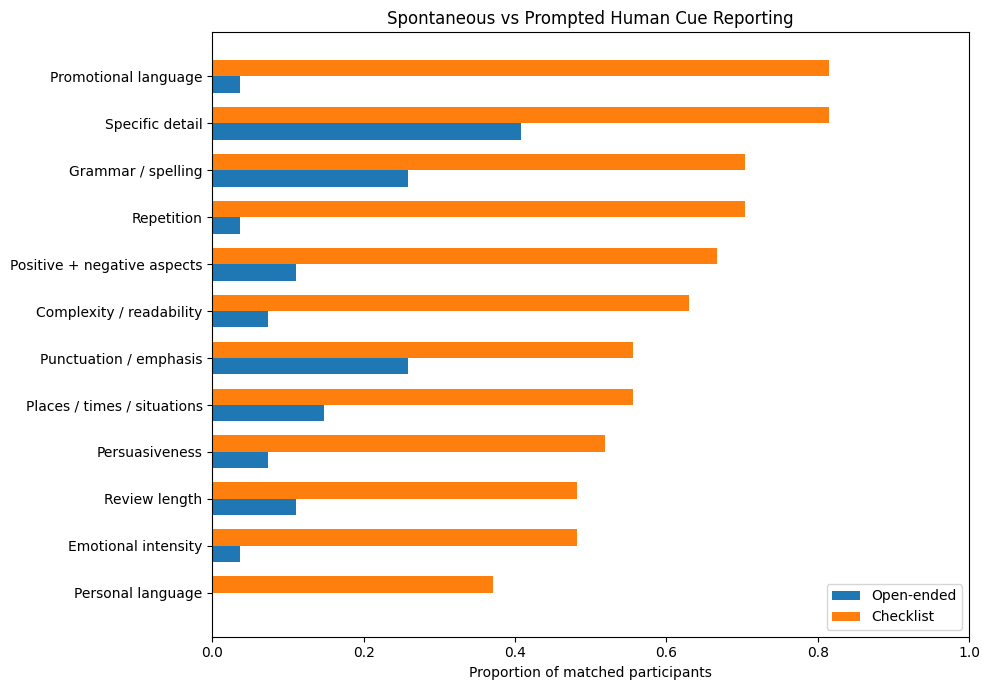

In [ ]:
plot_df = (
    matched_cue_df
    .copy()
)


plot_df[
    "label"
] = (
    plot_df[
        "code"
    ]
    .map(
        CUE_LABELS
    )
)


plot_df = (
    plot_df
    .sort_values(
        "checklist_proportion"
    )
    .reset_index(
        drop=True
    )
)


y = np.arange(
    len(
        plot_df
    )
)


height = 0.35


fig, ax = plt.subplots(
    figsize=(10, 7)
)


ax.barh(
    y - height / 2,
    plot_df[
        "spontaneous_proportion"
    ],
    height,
    label="Open-ended"
)


ax.barh(
    y + height / 2,
    plot_df[
        "checklist_proportion"
    ],
    height,
    label="Checklist"
)


ax.set_yticks(
    y
)


ax.set_yticklabels(
    plot_df[
        "label"
    ]
)


ax.set_xlim(
    0,
    1
)


ax.set_xlabel(
    "Proportion of matched participants"
)


ax.set_title(
    "Spontaneous vs Prompted Human Cue Reporting"
)


ax.legend()


fig.tight_layout()


fig.savefig(
    FIGURES_DIR /
    "human_open_vs_checklist_cues.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Part B — Observable Linguistic Cue Proxies

## 21. Linguistic Proxy Analysis

Observable linguistic features are selected using two complementary sources:

1. cues reported by participants in the human experiment;
2. linguistic dimensions previously investigated in research on deceptive online reviews.

The literature-guided dimensions include affective, perceptual-contextual, cognitive, certainty, complexity, readability, and temporal-detail cues. Human-reported cues additionally motivate measures related to mixed evaluation, personal language, promotional language, punctuation, and repetition.

The selected variables are computational proxies rather than direct measurements of psychological constructs. For example, a rate of sensory terms is treated as a proxy for perceptual detail, and contrast markers are treated as a proxy for mixed evaluation.

Published findings are used to motivate feature selection, not to predetermine the expected direction of effects in the present corpus, because prior studies use different review domains, deception mechanisms, and data-generation procedures.

In [ ]:
feature_plan = pd.DataFrame({

    "dimension": [
        "Quantity / Cognitive load",
        "Quantity / Cognitive load",
        "Readability / Complexity",
        "Personal language",
        "Affective",
        "Affective",
        "Certainty",
        "Certainty",
        "Cognitive processes",
        "Perceptual detail",
        "Contextual detail",
        "Mixed evaluation",
        "Promotional language",
        "Punctuation / emphasis",
        "Repetition"
    ],

    "feature": [
        "n_words",
        "mean_sentence_length",
        "automated_readability_index",
        "first_person_rate",
        "positive_affect_rate",
        "negative_affect_rate",
        "certainty_rate",
        "hedge_rate",
        "cognitive_process_rate",
        "perceptual_rate",
        "temporal_spatial_rate",
        "contrast_marker_rate",
        "promotional_rate",
        "exclamation_rate",
        "repetition_rate"
    ],

    "motivation": [
        "Literature + human cue",
        "Huang et al.",
        "Petrescu et al. + human cue",
        "Human cue + deception literature",
        "Zhang et al.; Petrescu et al.; Huang et al.",
        "Zhang et al.; Petrescu et al.; Huang et al.",
        "Huang et al.",
        "Huang et al.",
        "Zhang et al.; Huang et al.",
        "Zhang et al.; Huang et al.",
        "Zhang et al.; Petrescu et al.; Huang et al. + human cue",
        "Human cue",
        "Human cue + affect/self-presentation literature",
        "Human cue + Huang et al.",
        "Human cue + cognitive-load account"
    ]
})


display(
    feature_plan
)

,dimension,feature,motivation
0,Quantity / Cognitive load,n_words,Literature + human cue
1,Quantity / Cognitive load,mean_sentence_length,Huang et al.
2,Readability / Complexity,automated_readability_index,Petrescu et al. + human cue
3,Personal language,first_person_rate,Human cue + deception literature
4,Affective,positive_affect_rate,Zhang et al.; Petrescu et al.; Huang et al.
5,Affective,negative_affect_rate,Zhang et al.; Petrescu et al.; Huang et al.
6,Certainty,certainty_rate,Huang et al.
7,Certainty,hedge_rate,Huang et al.
8,Cognitive processes,cognitive_process_rate,Zhang et al.; Huang et al.
9,Perceptual detail,perceptual_rate,Zhang et al.; Huang et al.


In [ ]:
import re


FIRST_PERSON_WORDS = {
    "i",
    "me",
    "my",
    "mine",
    "myself",
    "we",
    "us",
    "our",
    "ours",
    "ourselves"
}


CONTRAST_MARKERS = {
    "but",
    "however",
    "although",
    "though",
    "yet",
    "despite",
    "while"
}


TEMPORAL_MARKERS = {
    "morning",
    "afternoon",
    "evening",
    "night",
    "day",
    "days",
    "week",
    "weeks",
    "weekend",
    "month",
    "months",
    "year",
    "years",
    "january",
    "february",
    "march",
    "april",
    "may",
    "june",
    "july",
    "august",
    "september",
    "october",
    "november",
    "december"
}


PROMOTIONAL_WORDS = {
    "amazing",
    "excellent",
    "perfect",
    "fantastic",
    "wonderful",
    "outstanding",
    "incredible",
    "awesome",
    "best",
    "luxurious",
    "luxury",
    "exceptional"
}

In [ ]:
def get_words(
    text
):

    words = re.findall(
        r"\b[a-zA-Z']+\b",
        str(text).lower()
    )

    return words

In [ ]:
def get_sentences(
    text
):

    sentences = re.split(
        r"[.!?]+",
        str(text)
    )


    sentences = [
        sentence.strip()
        for sentence in sentences
        if sentence.strip()
    ]


    return sentences

In [ ]:
def extract_linguistic_features(
    text
):

    text = str(
        text
    )


    words = get_words(
        text
    )


    sentences = get_sentences(
        text
    )


    n_words = len(
        words
    )


    if n_words == 0:

        return None


    # First-person language

    first_person_count = sum(
        word in FIRST_PERSON_WORDS
        for word in words
    )


    # Contrast markers

    contrast_count = sum(
        word in CONTRAST_MARKERS
        for word in words
    )


    # Temporal references

    temporal_count = sum(
        word in TEMPORAL_MARKERS
        for word in words
    )


    # Numerical references

    number_count = len(
        re.findall(
            r"\b\d+\b",
            text
        )
    )


    # Promotional markers

    promotional_count = sum(
        word in PROMOTIONAL_WORDS
        for word in words
    )


    # Exclamation marks

    exclamation_count = (
        text.count(
            "!"
        )
    )


    # Uppercase words

    original_words = re.findall(
        r"\b[A-Za-z]+\b",
        text
    )


    uppercase_count = sum(
        word.isupper()
        and len(word) > 1
        for word in original_words
    )


    # Lexical diversity

    lexical_diversity = (
        len(
            set(words)
        )
        /
        n_words
    )


    # Repetition

    repeated_words = (
        n_words
        -
        len(
            set(words)
        )
    )


    repetition_rate = (
        repeated_words
        /
        n_words
    )


    # Mean sentence length

    if len(sentences) > 0:

        mean_sentence_length = (
            n_words
            /
            len(sentences)
        )

    else:

        mean_sentence_length = np.nan


    return {

        "n_words":
            n_words,

        "first_person_rate":
            100
            * first_person_count
            / n_words,

        "contrast_marker_rate":
            100
            * contrast_count
            / n_words,

        "specificity_marker_rate":
            100
            * (
                temporal_count
                +
                number_count
            )
            / n_words,

        "promotional_marker_rate":
            100
            * promotional_count
            / n_words,

        "exclamation_rate":
            100
            * exclamation_count
            / n_words,

        "uppercase_rate":
            100
            * uppercase_count
            / n_words,

        "lexical_diversity":
            lexical_diversity,

        "repetition_rate":
            repetition_rate,

        "mean_sentence_length":
            mean_sentence_length
    }

In [ ]:
feature_rows = []


for _, row in df_clean.iterrows():

    features = (
        extract_linguistic_features(
            row[
                "text"
            ]
        )
    )


    features[
        "review_id"
    ] = row[
        "review_id"
    ]


    features[
        "label"
    ] = row[
        "label"
    ]


    feature_rows.append(
        features
    )


linguistic_features_df = pd.DataFrame(
    feature_rows
)


print(
    "Reviews:",
    len(
        linguistic_features_df
    )
)


print(
    "Missing values:"
)


print(
    linguistic_features_df
    .isna()
    .sum()
)


display(
    linguistic_features_df.head()
)

Reviews: 800
Missing values:
n_words                    0
first_person_rate          0
contrast_marker_rate       0
specificity_marker_rate    0
promotional_marker_rate    0
exclamation_rate           0
uppercase_rate             0
lexical_diversity          0
repetition_rate            0
mean_sentence_length       0
review_id                  0
label                      0
dtype: int64


,n_words,first_person_rate,contrast_marker_rate,specificity_marker_rate,promotional_marker_rate,exclamation_rate,uppercase_rate,lexical_diversity,repetition_rate,mean_sentence_length,review_id,label
0,103,2.912621,1.941748,2.912621,0.00000,0.0,1.941748,0.737864,0.262136,12.875000,R0000,truthful
1,43,0.000000,0.000000,2.325581,0.00000,0.0,0.000000,0.860465,0.139535,8.600000,R0001,truthful
2,205,6.341463,2.439024,3.414634,0.97561,0.0,0.487805,0.648780,0.351220,22.777778,R0002,truthful
3,125,2.400000,0.800000,1.600000,0.00000,1.6,0.000000,0.664000,0.336000,17.857143,R0003,truthful
4,72,6.944444,1.388889,0.000000,0.00000,0.0,0.000000,0.763889,0.236111,14.400000,R0004,truthful


## 22. Validate Linguistic Features

Feature distributions are inspected before comparing corpus labels to detect possible implementation errors or implausible values.

In [ ]:
display(
    linguistic_features_df[
        [
            "n_words",
            "first_person_rate",
            "contrast_marker_rate",
            "specificity_marker_rate",
            "promotional_marker_rate",
            "exclamation_rate",
            "uppercase_rate",
            "lexical_diversity",
            "repetition_rate",
            "mean_sentence_length"
        ]
    ]
    .describe()
    .round(3)
)

,n_words,first_person_rate,contrast_marker_rate,specificity_marker_rate,promotional_marker_rate,exclamation_rate,uppercase_rate,lexical_diversity,repetition_rate,mean_sentence_length
count,800.000,800.000,800.000,800.000,800.000,800.000,800.000,800.000,800.000,800.000
mean,118.901,5.554,0.686,1.577,1.234,0.972,0.376,0.695,0.305,14.810
std,64.449,3.076,0.891,1.913,1.305,1.588,3.465,0.082,0.082,6.152
min,25.000,0.000,0.000,0.000,0.000,0.000,0.000,0.459,0.073,4.778
25%,75.750,3.313,0.000,0.000,0.000,0.000,0.000,0.638,0.252,11.372
50%,104.500,5.536,0.000,1.128,1.005,0.000,0.000,0.695,0.305,13.714
75%,144.250,7.692,1.182,2.301,1.822,1.447,0.000,0.748,0.362,16.900
max,430.000,14.474,6.897,21.569,9.677,10.638,96.386,0.927,0.541,84.500


## 23. Compare Linguistic Proxies by Corpus Label

The linguistic proxies are summarized separately for truthful and deceptive reviews.

Both means and medians are reported because several surface linguistic measures may have skewed distributions.

In [ ]:
FEATURE_COLUMNS = [
    "n_words",
    "first_person_rate",
    "contrast_marker_rate",
    "specificity_marker_rate",
    "promotional_marker_rate",
    "exclamation_rate",
    "uppercase_rate",
    "lexical_diversity",
    "repetition_rate",
    "mean_sentence_length"
]


feature_summary_df = (
    linguistic_features_df
    .groupby(
        "label"
    )[
        FEATURE_COLUMNS
    ]
    .agg(
        [
            "mean",
            "median"
        ]
    )
)


display(
    feature_summary_df.round(3)
)

n_words        first_person_rate        contrast_marker_rate  \
              mean median              mean median                 mean   
label                                                                     
deceptive  115.840  103.0             6.402  6.528                0.545   
truthful   121.962  106.0             4.706  4.711                0.827   

                 specificity_marker_rate        promotional_marker_rate  \
          median                    mean median                    mean   
label                                                                     
deceptive  0.000                   0.932  0.714                   1.403   
truthful   0.694                   2.222  1.821                   1.065   

                 exclamation_rate        uppercase_rate         \
          median             mean median           mean median   
label                                                            
deceptive  1.197            1.162  0.529          0.427    0.0   
truthful   0.761            0.782  0.000          0.325    0.0   

          lexical_diversity        repetition_rate         \
                       mean median            mean median   
label                                                       
deceptive             0.688  0.684           0.312  0.316   
truthful              0.703  0.700           0.297  0.300   

          mean_sentence_length          
                          mean  median  
label                                   
deceptive               15.140  14.059  
truthful                14.481  13.236

In [ ]:
def automated_readability_index(
    text
):

    text = str(
        text
    )


    words = get_words(
        text
    )


    sentences = get_sentences(
        text
    )


    n_words = max(
        len(words),
        1
    )


    n_sentences = max(
        len(sentences),
        1
    )


    n_characters = sum(
        len(word)
        for word in words
    )


    ari = (
        4.71
        * (
            n_characters
            /
            n_words
        )
        +
        0.5
        * (
            n_words
            /
            n_sentences
        )
        -
        21.43
    )


    return ari

In [ ]:
linguistic_features_df[
    "readability_ari"
] = (
    df_clean[
        "text"
    ]
    .apply(
        automated_readability_index
    )
)


print(
    linguistic_features_df[
        "readability_ari"
    ].describe()
)

count    800.000000
mean       6.674173
std        3.234224
min        0.524532
25%        4.876698
50%        6.223726
75%        7.889695
max       40.496095
Name: readability_ari, dtype: float64


In [ ]:
import nltk


nltk.download(
    "opinion_lexicon",
    quiet=True
)


from nltk.corpus import opinion_lexicon


POSITIVE_WORDS = set(
    opinion_lexicon.positive()
)


NEGATIVE_WORDS = set(
    opinion_lexicon.negative()
)

In [ ]:
def affect_rates(
    text
):

    words = get_words(
        text
    )


    n_words = max(
        len(words),
        1
    )


    positive_count = sum(
        word in POSITIVE_WORDS
        for word in words
    )


    negative_count = sum(
        word in NEGATIVE_WORDS
        for word in words
    )


    return pd.Series(
        {
            "positive_affect_rate":
                100
                * positive_count
                / n_words,

            "negative_affect_rate":
                100
                * negative_count
                / n_words
        }
    )

In [ ]:
affect_df = (
    df_clean[
        "text"
    ]
    .apply(
        affect_rates
    )
)


linguistic_features_df = pd.concat(
    [
        linguistic_features_df,
        affect_df
    ],
    axis=1
)


display(
    linguistic_features_df[
        [
            "positive_affect_rate",
            "negative_affect_rate"
        ]
    ]
    .describe()
    .round(3)
)

,positive_affect_rate,negative_affect_rate
count,800.000,800.000
mean,8.889,0.841
std,3.375,1.062
min,1.818,0.000
25%,6.590,0.000
50%,8.333,0.563
75%,10.643,1.416
max,23.333,7.042


## 24. Theory-Guided Lexical Proxies

Additional lexical proxies are defined for theoretical dimensions identified in previous deception research:

- certainty and hedging;
- cognitive-process language;
- perceptual information;
- temporal information;
- spatial information.

The dictionaries are intentionally small and transparent. They are not intended to reproduce proprietary LIWC categories or to provide exhaustive linguistic measurements.

All dictionaries are fixed before examining their association with the corpus labels.

In [ ]:
CERTAINTY_WORDS = {
    "always",
    "never",
    "definitely",
    "certainly",
    "clearly",
    "absolutely",
    "surely",
    "undoubtedly",
    "obviously",
    "must"
}


HEDGE_WORDS = {
    "maybe",
    "perhaps",
    "probably",
    "possibly",
    "apparently",
    "seem",
    "seems",
    "seemed",
    "likely",
    "somewhat"
}


COGNITIVE_PROCESS_WORDS = {
    "think",
    "thought",
    "know",
    "knew",
    "believe",
    "believed",
    "realize",
    "realized",
    "understand",
    "understood",
    "remember",
    "remembered",
    "consider",
    "considered",
    "decide",
    "decided",
    "expect",
    "expected",
    "because",
    "reason",
    "reasons",
    "cause",
    "causes",
    "caused"
}


PERCEPTUAL_WORDS = {
    "see",
    "saw",
    "seen",
    "look",
    "looked",
    "looking",
    "hear",
    "heard",
    "sound",
    "sounds",
    "smell",
    "smelled",
    "scent",
    "taste",
    "tasted",
    "touch",
    "touched",
    "feel",
    "felt"
}


TEMPORAL_WORDS = {
    "today",
    "yesterday",
    "tomorrow",
    "morning",
    "afternoon",
    "evening",
    "night",
    "nights",
    "day",
    "days",
    "week",
    "weeks",
    "weekend",
    "month",
    "months",
    "year",
    "years",
    "before",
    "after",
    "during",
    "later",
    "earlier",
    "recently",
    "finally",

    "january",
    "february",
    "march",
    "april",
    "may",
    "june",
    "july",
    "august",
    "september",
    "october",
    "november",
    "december"
}


SPATIAL_WORDS = {
    "here",
    "there",
    "near",
    "nearby",
    "inside",
    "outside",
    "upstairs",
    "downstairs",
    "across",
    "behind",
    "beside",
    "between"
}

In [ ]:
def theory_guided_rates(
    text
):

    words = get_words(
        text
    )


    n_words = max(
        len(words),
        1
    )


    certainty_count = sum(
        word in CERTAINTY_WORDS
        for word in words
    )


    hedge_count = sum(
        word in HEDGE_WORDS
        for word in words
    )


    cognitive_count = sum(
        word in COGNITIVE_PROCESS_WORDS
        for word in words
    )


    perceptual_count = sum(
        word in PERCEPTUAL_WORDS
        for word in words
    )


    temporal_count = sum(
        word in TEMPORAL_WORDS
        for word in words
    )


    spatial_count = sum(
        word in SPATIAL_WORDS
        for word in words
    )


    numeric_count = len(
        re.findall(
            r"\b\d+(?:\.\d+)?\b",
            str(text)
        )
    )


    return pd.Series(
        {

            "certainty_rate":
                100
                * certainty_count
                / n_words,

            "hedge_rate":
                100
                * hedge_count
                / n_words,

            "cognitive_process_rate":
                100
                * cognitive_count
                / n_words,

            "perceptual_rate":
                100
                * perceptual_count
                / n_words,

            "temporal_reference_rate":
                100
                * temporal_count
                / n_words,

            "spatial_reference_rate":
                100
                * spatial_count
                / n_words,

            "numeric_reference_rate":
                100
                * numeric_count
                / n_words
        }
    )

In [ ]:
theory_features_df = (
    df_clean[
        "text"
    ]
    .apply(
        theory_guided_rates
    )
)


linguistic_features_df = pd.concat(
    [
        linguistic_features_df,
        theory_features_df
    ],
    axis=1
)


display(
    linguistic_features_df[
        [
            "certainty_rate",
            "hedge_rate",
            "cognitive_process_rate",
            "perceptual_rate",
            "temporal_reference_rate",
            "spatial_reference_rate",
            "numeric_reference_rate"
        ]
    ]
    .describe()
    .round(3)
)

,certainty_rate,hedge_rate,cognitive_process_rate,perceptual_rate,temporal_reference_rate,spatial_reference_rate,numeric_reference_rate
count,800.000,800.000,800.000,800.000,800.000,800.000,800.000
mean,0.513,0.086,0.348,0.491,1.295,0.843,0.719
std,0.791,0.315,0.643,0.727,1.295,1.008,1.361
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,1.097,0.699,0.000
75%,0.901,0.000,0.576,0.893,1.961,1.351,1.093
max,4.651,3.030,3.947,5.357,8.889,6.061,19.608


## 25. Inspect Lexical Feature Sparsity

Because dictionary-based linguistic features may occur infrequently, the proportion of reviews containing at least one occurrence of each feature is inspected before statistical analysis.

In [ ]:
LEXICAL_FEATURES = [
    "certainty_rate",
    "hedge_rate",
    "cognitive_process_rate",
    "perceptual_rate",
    "temporal_reference_rate",
    "spatial_reference_rate",
    "numeric_reference_rate",
    "positive_affect_rate",
    "negative_affect_rate"
]


sparsity_rows = []


for feature in LEXICAL_FEATURES:

    nonzero = (
        linguistic_features_df[
            feature
        ] > 0
    )


    sparsity_rows.append(
        {
            "feature":
                feature,

            "n_nonzero":
                int(
                    nonzero.sum()
                ),

            "proportion_nonzero":
                nonzero.mean()
        }
    )


sparsity_df = pd.DataFrame(
    sparsity_rows
)


display(
    sparsity_df.round(3)
)

,feature,n_nonzero,proportion_nonzero
0,certainty_rate,323,0.404
1,hedge_rate,77,0.096
2,cognitive_process_rate,243,0.304
3,perceptual_rate,334,0.418
4,temporal_reference_rate,542,0.678
5,spatial_reference_rate,450,0.562
6,numeric_reference_rate,313,0.391
7,positive_affect_rate,800,1.000
8,negative_affect_rate,427,0.534


## 26. Freeze the Primary Linguistic Feature Set

The primary linguistic feature set is frozen before label-based statistical testing.

Features from preliminary exploration that overlap strongly with more interpretable measures, or that are weakly theoretically motivated, are excluded from the primary analysis.

In [ ]:
PRIMARY_FEATURES = [

    # Quantity / complexity

    "n_words",
    "mean_sentence_length",
    "readability_ari",

    # Personal language

    "first_person_rate",

    # Affect

    "positive_affect_rate",
    "negative_affect_rate",

    # Certainty

    "certainty_rate",
    "hedge_rate",

    # Cognitive processes

    "cognitive_process_rate",

    # Perceptual and contextual detail

    "perceptual_rate",
    "temporal_reference_rate",
    "spatial_reference_rate",
    "numeric_reference_rate",

    # Human-motivated surface cues

    "contrast_marker_rate",
    "promotional_marker_rate",
    "exclamation_rate",
    "repetition_rate"
]


print(
    "Primary features:",
    len(
        PRIMARY_FEATURES
    )
)


print()


for feature in PRIMARY_FEATURES:

    print(
        feature
    )

Primary features: 17

n_words
mean_sentence_length
readability_ari
first_person_rate
positive_affect_rate
negative_affect_rate
certainty_rate
hedge_rate
cognitive_process_rate
perceptual_rate
temporal_reference_rate
spatial_reference_rate
numeric_reference_rate
contrast_marker_rate
promotional_marker_rate
exclamation_rate
repetition_rate


## 27. Statistical Comparison of Linguistic Features

The fixed set of linguistic features is compared between truthful and deceptive reviews.

Many rate-based features are not normally distributed and contain many zero values. For this reason, two-sided Mann–Whitney U tests are used instead of relying only on differences in mean values.

The size of the differences is measured using Cliff's delta. A positive value indicates that a feature tends to be higher in deceptive reviews, while a negative value indicates that it tends to be higher in truthful reviews.

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


stat_rows = []


for feature in PRIMARY_FEATURES:

    deceptive_values = (
        linguistic_features_df.loc[
            linguistic_features_df[
                "label"
            ] == "deceptive",
            feature
        ]
        .dropna()
        .values
    )


    truthful_values = (
        linguistic_features_df.loc[
            linguistic_features_df[
                "label"
            ] == "truthful",
            feature
        ]
        .dropna()
        .values
    )


    u_statistic, p_value = mannwhitneyu(
        deceptive_values,
        truthful_values,
        alternative="two-sided"
    )


    n_deceptive = len(
        deceptive_values
    )


    n_truthful = len(
        truthful_values
    )


    cliffs_delta = (
        2
        * u_statistic
        /
        (
            n_deceptive
            *
            n_truthful
        )
        -
        1
    )


    stat_rows.append(
        {
            "feature":
                feature,

            "deceptive_mean":
                deceptive_values.mean(),

            "truthful_mean":
                truthful_values.mean(),

            "deceptive_median":
                np.median(
                    deceptive_values
                ),

            "truthful_median":
                np.median(
                    truthful_values
                ),

            "cliffs_delta":
                cliffs_delta,

            "p_value":
                p_value
        }
    )


feature_stats_df = pd.DataFrame(
    stat_rows
)

In [ ]:
reject, corrected_p, _, _ = (
    multipletests(
        feature_stats_df[
            "p_value"
        ],
        method="fdr_bh"
    )
)


feature_stats_df[
    "p_fdr"
] = corrected_p


feature_stats_df[
    "significant_fdr"
] = reject

In [ ]:
feature_stats_df[
    "direction"
] = np.where(
    feature_stats_df[
        "cliffs_delta"
    ] > 0,
    "deceptive higher",
    "truthful higher"
)


feature_stats_df[
    "abs_delta"
] = (
    feature_stats_df[
        "cliffs_delta"
    ]
    .abs()
)


feature_stats_df = (
    feature_stats_df
    .sort_values(
        "abs_delta",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    feature_stats_df[
        [
            "feature",
            "deceptive_mean",
            "truthful_mean",
            "deceptive_median",
            "truthful_median",
            "cliffs_delta",
            "direction",
            "p_value",
            "p_fdr",
            "significant_fdr"
        ]
    ]
    .round(4)
)

,feature,deceptive_mean,truthful_mean,deceptive_median,truthful_median,cliffs_delta,direction,p_value,p_fdr,significant_fdr
0,numeric_reference_rate,0.2923,1.1451,0.0000,0.6601,-0.3529,truthful higher,0.0000,0.0000,True
1,first_person_rate,6.4016,4.7055,6.5282,4.7114,0.3199,deceptive higher,0.0000,0.0000,True
2,negative_affect_rate,0.6326,1.0492,0.0000,0.8475,-0.2354,truthful higher,0.0000,0.0000,True
3,contrast_marker_rate,0.5448,0.8271,0.0000,0.6944,-0.1846,truthful higher,0.0000,0.0000,True
4,promotional_marker_rate,1.4026,1.0655,1.1966,0.7606,0.1784,deceptive higher,0.0000,0.0000,True
5,temporal_reference_rate,1.0711,1.5197,0.9259,1.2122,-0.1724,truthful higher,0.0000,0.0000,True
6,mean_sentence_length,15.1400,14.4808,14.0588,13.2361,0.1504,deceptive higher,0.0002,0.0005,True
7,exclamation_rate,1.1616,0.7820,0.5295,0.0000,0.1431,deceptive higher,0.0001,0.0003,True
8,positive_affect_rate,9.2332,8.5458,8.8235,8.0000,0.1399,deceptive higher,0.0006,0.0010,True
9,perceptual_rate,0.6029,0.3789,0.0000,0.0000,0.1319,deceptive higher,0.0003,0.0006,True


In [ ]:
CORPUS_CUE_RESULTS_PATH = (
    RESULTS_DIR /
    "linguistic_cue_truthful_vs_deceptive.csv"
)


feature_stats_df.to_csv(
    CORPUS_CUE_RESULTS_PATH,
    index=False
)


print(
    "Saved:",
    CORPUS_CUE_RESULTS_PATH
)

Saved: /content/drive/MyDrive/HLT_project/results/linguistic_cue_truthful_vs_deceptive.csv


## 28. Fold-Level Robustness of Linguistic Effects

To check if these language differences hold true across all the original hotel groups, we re-calculate Cliff’s delta for each group separately.


In [ ]:
if "fold" not in linguistic_features_df.columns:

    linguistic_features_df = (
        linguistic_features_df
        .merge(
            df_clean[
                [
                    "review_id",
                    "fold"
                ]
            ],
            on="review_id",
            how="left"
        )
    )


print(
    linguistic_features_df[
        "fold"
    ].value_counts()
    .sort_index()
)

fold
fold1    160
fold2    160
fold3    160
fold4    160
fold5    160
Name: count, dtype: int64


In [ ]:
fold_effect_rows = []


for fold in sorted(
    linguistic_features_df[
        "fold"
    ].unique()
):

    fold_df = (
        linguistic_features_df[
            linguistic_features_df[
                "fold"
            ] == fold
        ]
    )


    for feature in PRIMARY_FEATURES:

        deceptive_values = (
            fold_df.loc[
                fold_df[
                    "label"
                ] == "deceptive",
                feature
            ]
            .dropna()
            .values
        )


        truthful_values = (
            fold_df.loc[
                fold_df[
                    "label"
                ] == "truthful",
                feature
            ]
            .dropna()
            .values
        )


        u_statistic, _ = mannwhitneyu(
            deceptive_values,
            truthful_values,
            alternative="two-sided"
        )


        cliffs_delta = (
            2
            * u_statistic
            /
            (
                len(
                    deceptive_values
                )
                *
                len(
                    truthful_values
                )
            )
            -
            1
        )


        fold_effect_rows.append(
            {
                "fold":
                    fold,

                "feature":
                    feature,

                "cliffs_delta":
                    cliffs_delta
            }
        )


fold_effects_df = pd.DataFrame(
    fold_effect_rows
)

In [ ]:
overall_direction_df = (
    feature_stats_df[
        [
            "feature",
            "cliffs_delta"
        ]
    ]
    .rename(
        columns={
            "cliffs_delta":
                "overall_delta"
        }
    )
)

In [ ]:
fold_consistency_rows = []


for feature in PRIMARY_FEATURES:

    feature_fold_df = (
        fold_effects_df[
            fold_effects_df[
                "feature"
            ] == feature
        ]
    )


    overall_delta = (
        overall_direction_df.loc[
            overall_direction_df[
                "feature"
            ] == feature,
            "overall_delta"
        ]
        .iloc[0]
    )


    if overall_delta > 0:

        same_direction = (
            feature_fold_df[
                "cliffs_delta"
            ] > 0
        )

    elif overall_delta < 0:

        same_direction = (
            feature_fold_df[
                "cliffs_delta"
            ] < 0
        )

    else:

        same_direction = (
            feature_fold_df[
                "cliffs_delta"
            ] == 0
        )


    fold_consistency_rows.append(
        {
            "feature":
                feature,

            "overall_delta":
                overall_delta,

            "folds_same_direction":
                int(
                    same_direction.sum()
                ),

            "mean_fold_delta":
                feature_fold_df[
                    "cliffs_delta"
                ].mean(),

            "min_fold_delta":
                feature_fold_df[
                    "cliffs_delta"
                ].min(),

            "max_fold_delta":
                feature_fold_df[
                    "cliffs_delta"
                ].max()
        }
    )


fold_consistency_df = pd.DataFrame(
    fold_consistency_rows
)

In [ ]:
fold_consistency_df[
    "abs_overall_delta"
] = (
    fold_consistency_df[
        "overall_delta"
    ].abs()
)


fold_consistency_df = (
    fold_consistency_df
    .sort_values(
        "abs_overall_delta",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    fold_consistency_df[
        [
            "feature",
            "overall_delta",
            "folds_same_direction",
            "mean_fold_delta",
            "min_fold_delta",
            "max_fold_delta"
        ]
    ]
    .round(3)
)

,feature,overall_delta,folds_same_direction,mean_fold_delta,min_fold_delta,max_fold_delta
0,numeric_reference_rate,-0.353,5,-0.354,-0.450,-0.262
1,first_person_rate,0.320,5,0.316,0.253,0.395
2,negative_affect_rate,-0.235,5,-0.239,-0.325,-0.149
3,contrast_marker_rate,-0.185,4,-0.184,-0.402,0.009
4,promotional_marker_rate,0.178,5,0.176,0.066,0.248
5,temporal_reference_rate,-0.172,5,-0.174,-0.373,-0.027
6,mean_sentence_length,0.150,5,0.151,0.096,0.218
7,exclamation_rate,0.143,5,0.143,0.117,0.172
8,positive_affect_rate,0.140,4,0.138,-0.022,0.269
9,perceptual_rate,0.132,5,0.135,0.048,0.248




## 29. Inspect Available Human and Model Outputs

The next analysis investigates whether observable linguistic features are associated with the decisions of humans, Qwen, and RoBERTa.

Whenever available, continuous decision scores are preferred over binary predictions because they preserve information about the strength of the system's preference for the deceptive class.

Before constructing the comparison dataset, the available columns are inspected without modifying any previous results.

In [ ]:
human_long_df = pd.read_csv(
    PROCESSED_HUMAN_DIR /
    "human_judgments_long.csv"
)


human_model_df = pd.read_csv(
    PROCESSED_HUMAN_DIR /
    "human_model_comparison_120.csv"
)


qwen_df = pd.read_csv(
    RESULTS_DIR /
    "qwen_counterbalanced_full_results_final.csv"
)


roberta_df = pd.read_csv(
    RESULTS_DIR /
    "roberta_5fold_out_of_fold_predictions.csv"
)


print("HUMAN LONG")
print(human_long_df.columns.tolist())

print()


print("HUMAN-MODEL 120")
print(human_model_df.columns.tolist())

print()


print("QWEN")
print(qwen_df.columns.tolist())

print()


print("ROBERTA")
print(roberta_df.columns.tolist())

HUMAN LONG
['participant_id', 'block', 'review_number', 'review_id', 'gold_label', 'prediction', 'confidence']

HUMAN-MODEL 120
['review_id', 'block', 'gold_label', 'n_judgments', 'n_truthful', 'n_deceptive', 'human_prediction', 'human_correct', 'qwen_prediction', 'roberta_prediction', 'qwen_correct', 'roberta_correct']

QWEN
['review_id', 'gold_label', 'hotel', 'fold', 'prediction', 'prediction_mapping_1', 'prediction_mapping_2', 'same_mapping_prediction', 'deception_score', 'deception_score_mapping_1', 'deception_score_mapping_2', 'p_deceptive', 'p_truthful', 'correct', 'absolute_score', 'score_quartile']

ROBERTA
['review_id', 'hotel', 'fold', 'gold_label', 'prediction', 'p_truthful', 'p_deceptive', 'correct']


In [ ]:
display(
    human_long_df.head(3)
)


display(
    qwen_df.head(3)
)


display(
    roberta_df.head(3)
)

,participant_id,block,review_number,review_id,gold_label,prediction,confidence
0,B1_P001,B1,1,R0446,deceptive,truthful,4
1,B1_P001,B1,2,R0483,deceptive,truthful,5
2,B1_P001,B1,3,R0699,deceptive,deceptive,3


,review_id,gold_label,hotel,fold,prediction,prediction_mapping_1,prediction_mapping_2,same_mapping_prediction,deception_score,deception_score_mapping_1,deception_score_mapping_2,p_deceptive,p_truthful,correct,absolute_score,score_quartile
0,R0000,truthful,conrad,fold3,truthful,deceptive,truthful,False,-1.3750,3.750,-6.50,0.201813,0.798187,True,1.3750,Q1 — weakest
1,R0001,truthful,hyatt,fold3,deceptive,deceptive,deceptive,True,5.3125,8.875,1.75,0.995095,0.004905,False,5.3125,Q2
2,R0002,truthful,hyatt,fold3,deceptive,deceptive,truthful,False,4.5000,10.500,-1.50,0.989013,0.010987,False,4.5000,Q2


,review_id,hotel,fold,gold_label,prediction,p_truthful,p_deceptive,correct
0,R0240,hilton,fold1,truthful,truthful,0.998469,0.001531,True
1,R0241,hilton,fold1,truthful,truthful,0.998573,0.001427,True
2,R0242,james,fold1,truthful,deceptive,0.343975,0.656025,False


## 30. Review-Level Human Deception Tendency

Human decisions are aggregated at the review level as the proportion of judgments assigning the deceptive label.

This measure preserves disagreement between participants and provides a continuous measure of human deception tendency rather than reducing each review to a majority-vote label.

In [ ]:
human_review_df = (
    human_long_df
    .assign(
        deceptive_judgment=(
            human_long_df[
                "prediction"
            ] == "deceptive"
        ).astype(int)
    )
    .groupby(
        "review_id"
    )
    .agg(
        gold_label=(
            "gold_label",
            "first"
        ),
        n_judgments=(
            "participant_id",
            "count"
        ),
        n_deceptive=(
            "deceptive_judgment",
            "sum"
        )
    )
    .reset_index()
)


human_review_df[
    "human_deception_rate"
] = (
    human_review_df[
        "n_deceptive"
    ]
    /
    human_review_df[
        "n_judgments"
    ]
)


print(
    "Human reviews:",
    len(
        human_review_df
    )
)


display(
    human_review_df.head()
)

Human reviews: 120


,review_id,gold_label,n_judgments,n_deceptive,human_deception_rate
0,R0001,truthful,5,2,0.400000
1,R0005,truthful,6,1,0.166667
2,R0011,truthful,10,1,0.100000
3,R0014,truthful,5,0,0.000000
4,R0021,truthful,6,0,0.000000


In [ ]:
display(
    human_review_df[
        "n_judgments"
    ]
    .value_counts()
    .sort_index()
)

,count
n_judgments,
5,60
6,20
7,20
10,20


## 31. Combine Linguistic Features and System Outputs

The frozen linguistic features are combined with:

- the human review-level deception rate;
- Qwen's counterbalanced deception decision score;
- RoBERTa's out-of-fold deceptive-class score.

Qwen's `deception_score` is treated as a continuous decision margin rather than a calibrated probability.

In [ ]:
cue_decision_df = (
    linguistic_features_df[
        [
            "review_id",
            "label"
        ]
        +
        PRIMARY_FEATURES
    ]
    .rename(
        columns={
            "label":
                "gold_label"
        }
    )
    .merge(
        qwen_df[
            [
                "review_id",
                "deception_score",
                "prediction"
            ]
        ]
        .rename(
            columns={
                "deception_score":
                    "qwen_deception_score",
                "prediction":
                    "qwen_prediction"
            }
        ),
        on="review_id",
        how="inner"
    )
    .merge(
        roberta_df[
            [
                "review_id",
                "p_deceptive",
                "prediction"
            ]
        ]
        .rename(
            columns={
                "p_deceptive":
                    "roberta_deception_score",
                "prediction":
                    "roberta_prediction"
            }
        ),
        on="review_id",
        how="inner"
    )
    .merge(
        human_review_df[
            [
                "review_id",
                "human_deception_rate",
                "n_judgments"
            ]
        ],
        on="review_id",
        how="left"
    )
)


print(
    "Reviews with model outputs:",
    len(
        cue_decision_df
    )
)


print(
    "Reviews with human judgments:",
    cue_decision_df[
        "human_deception_rate"
    ].notna().sum()
)


print(
    "Missing model scores:"
)


print(
    cue_decision_df[
        [
            "qwen_deception_score",
            "roberta_deception_score"
        ]
    ]
    .isna()
    .sum()
)

Reviews with model outputs: 800
Reviews with human judgments: 120
Missing model scores:
qwen_deception_score       0
roberta_deception_score    0
dtype: int64


In [ ]:
display(
    cue_decision_df[
        [
            "human_deception_rate",
            "qwen_deception_score",
            "roberta_deception_score"
        ]
    ]
    .describe()
    .round(3)
)

,human_deception_rate,qwen_deception_score,roberta_deception_score
count,120.000,800.000,800.000
mean,0.397,3.578,0.517
std,0.242,6.835,0.493
min,0.000,-11.500,0.000
25%,0.200,-2.516,0.001
50%,0.400,4.406,0.974
75%,0.600,9.781,0.999
max,1.000,15.812,1.000


## 32. Raw Associations Between Linguistic Features and Decisions

Spearman correlations quantify monotonic associations between each linguistic feature and each system's tendency to classify a review as deceptive.

These raw correlations are descriptive and may partly reflect the relationship between linguistic features and the true corpus label.



In [ ]:
from scipy.stats import spearmanr


SYSTEM_SCORES = {
    "Humans":
        "human_deception_rate",

    "Qwen":
        "qwen_deception_score",

    "RoBERTa":
        "roberta_deception_score"
}


raw_rows = []


for system, score_column in (
    SYSTEM_SCORES.items()
):

    system_df = (
        cue_decision_df[
            cue_decision_df[
                score_column
            ].notna()
        ]
    )


    for feature in PRIMARY_FEATURES:

        rho, p_value = spearmanr(
            system_df[
                feature
            ],
            system_df[
                score_column
            ]
        )


        raw_rows.append(
            {
                "system":
                    system,

                "feature":
                    feature,

                "n_reviews":
                    len(
                        system_df
                    ),

                "rho_raw":
                    rho,

                "p_raw":
                    p_value
            }
        )


raw_association_df = pd.DataFrame(
    raw_rows
)

## 34. Gold-Adjusted Feature–Decision Associations

Raw feature-decision associations may arise simply because both the linguistic feature and the system decision are associated with the true review label.

To reduce this confounding, partial Spearman correlations are computed while controlling for the gold label.

The analysis therefore asks whether, among reviews with the same underlying class, variation in a linguistic feature is still associated with a stronger tendency to predict deception.

These associations are interpreted as behavioral evidence of cue sensitivity, not as direct proof of internal causal feature use.

In [ ]:
from scipy.stats import rankdata
from scipy.stats import t as t_distribution


def partial_spearman_binary_control(
    x,
    y,
    control
):

    x = np.asarray(
        x
    )

    y = np.asarray(
        y
    )

    control = np.asarray(
        control
    )


    x_rank = rankdata(
        x
    )


    y_rank = rankdata(
        y
    )


    design = np.column_stack(
        [
            np.ones(
                len(control)
            ),
            control
        ]
    )


    beta_x = np.linalg.lstsq(
        design,
        x_rank,
        rcond=None
    )[0]


    beta_y = np.linalg.lstsq(
        design,
        y_rank,
        rcond=None
    )[0]


    x_residual = (
        x_rank
        -
        design
        @ beta_x
    )


    y_residual = (
        y_rank
        -
        design
        @ beta_y
    )


    r = np.corrcoef(
        x_residual,
        y_residual
    )[0, 1]


    n = len(
        x
    )


    degrees_freedom = (
        n
        -
        3
    )


    t_value = (
        r
        *
        np.sqrt(
            degrees_freedom
            /
            (
                1
                -
                r ** 2
            )
        )
    )


    p_value = (
        2
        *
        t_distribution.sf(
            abs(
                t_value
            ),
            df=degrees_freedom
        )
    )


    return (
        r,
        p_value
    )

In [ ]:
adjusted_rows = []


for system, score_column in (
    SYSTEM_SCORES.items()
):

    system_df = (
        cue_decision_df[
            cue_decision_df[
                score_column
            ].notna()
        ]
        .copy()
    )


    system_df[
        "gold_deceptive"
    ] = (
        system_df[
            "gold_label"
        ]
        ==
        "deceptive"
    ).astype(int)


    for feature in PRIMARY_FEATURES:

        rho_adjusted, p_value = (
            partial_spearman_binary_control(
                system_df[
                    feature
                ],
                system_df[
                    score_column
                ],
                system_df[
                    "gold_deceptive"
                ]
            )
        )


        adjusted_rows.append(
            {
                "system":
                    system,

                "feature":
                    feature,

                "n_reviews":
                    len(
                        system_df
                    ),

                "rho_adjusted":
                    rho_adjusted,

                "p_adjusted":
                    p_value
            }
        )


adjusted_association_df = pd.DataFrame(
    adjusted_rows
)

In [ ]:
adjusted_result_parts = []


for system in (
    adjusted_association_df[
        "system"
    ].unique()
):

    system_results = (
        adjusted_association_df[
            adjusted_association_df[
                "system"
            ] == system
        ]
        .copy()
    )


    reject, p_fdr, _, _ = (
        multipletests(
            system_results[
                "p_adjusted"
            ],
            method="fdr_bh"
        )
    )


    system_results[
        "p_fdr"
    ] = p_fdr


    system_results[
        "significant_fdr"
    ] = reject


    adjusted_result_parts.append(
        system_results
    )


adjusted_association_df = pd.concat(
    adjusted_result_parts,
    ignore_index=True
)

In [ ]:
system_cue_results_df = (
    raw_association_df
    .merge(
        adjusted_association_df,
        on=[
            "system",
            "feature",
            "n_reviews"
        ],
        how="inner"
    )
)


system_cue_results_df[
    "abs_rho_adjusted"
] = (
    system_cue_results_df[
        "rho_adjusted"
    ].abs()
)


system_cue_results_df = (
    system_cue_results_df
    .sort_values(
        [
            "system",
            "abs_rho_adjusted"
        ],
        ascending=[
            True,
            False
        ]
    )
)


display(
    system_cue_results_df[
        [
            "system",
            "feature",
            "n_reviews",
            "rho_raw",
            "rho_adjusted",
            "p_fdr",
            "significant_fdr"
        ]
    ]
    .round(4)
)

,system,feature,n_reviews,rho_raw,rho_adjusted,p_fdr,significant_fdr
16,Humans,repetition_rate,120,0.1751,0.1695,0.5816,False
2,Humans,readability_ari,120,-0.1302,-0.1565,0.5816,False
13,Humans,contrast_marker_rate,120,-0.1827,-0.1481,0.5816,False
15,Humans,exclamation_rate,120,0.1310,0.1108,0.5816,False
0,Humans,n_words,120,0.1032,0.1095,0.5816,False
1,Humans,mean_sentence_length,120,-0.0708,-0.1040,0.5816,False
14,Humans,promotional_marker_rate,120,0.0894,0.0895,0.5816,False
5,Humans,negative_affect_rate,120,-0.1071,-0.0866,0.5816,False
3,Humans,first_person_rate,120,0.0071,-0.0843,0.5816,False
4,Humans,positive_affect_rate,120,-0.0799,-0.0831,0.5816,False


In [ ]:
system_comparison_df = (
    system_cue_results_df
    .pivot(
        index="feature",
        columns="system",
        values="rho_adjusted"
    )
    .reset_index()
)


system_comparison_df = (
    system_comparison_df
    .merge(
        feature_stats_df[
            [
                "feature",
                "cliffs_delta"
            ]
        ]
        .rename(
            columns={
                "cliffs_delta":
                    "Corpus"
            }
        ),
        on="feature",
        how="left"
    )
)


system_comparison_df = (
    system_comparison_df[
        [
            "feature",
            "Corpus",
            "Humans",
            "Qwen",
            "RoBERTa"
        ]
    ]
)


system_comparison_df[
    "max_system_association"
] = (
    system_comparison_df[
        [
            "Humans",
            "Qwen",
            "RoBERTa"
        ]
    ]
    .abs()
    .max(
        axis=1
    )
)


system_comparison_df = (
    system_comparison_df
    .sort_values(
        "max_system_association",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    system_comparison_df.round(3)
)

,feature,Corpus,Humans,Qwen,RoBERTa,max_system_association
0,numeric_reference_rate,-0.353,0.052,0.096,-0.236,0.236
1,repetition_rate,0.106,0.170,0.062,-0.084,0.170
2,positive_affect_rate,0.140,-0.083,-0.169,0.109,0.169
3,readability_ari,0.123,-0.156,-0.043,0.094,0.156
4,contrast_marker_rate,-0.185,-0.148,-0.059,-0.132,0.148
5,promotional_marker_rate,0.178,0.089,0.062,0.146,0.146
6,temporal_reference_rate,-0.172,-0.082,-0.142,-0.028,0.142
7,n_words,-0.044,0.109,0.116,-0.139,0.139
8,perceptual_rate,0.132,-0.021,0.130,-0.032,0.130
9,negative_affect_rate,-0.235,-0.087,0.080,-0.119,0.119


## 35. Directional Alignment with Corpus-Level Patterns

As a descriptive summary, the direction of each system's gold-adjusted feature association is compared with the direction of the corresponding corpus-level effect.

This measure is not treated as an inferential test because linguistic features are not independent and the corpus and system associations use different effect-size metrics.

For model associations surviving FDR correction, directional agreement is also summarized separately.

In [ ]:
alignment_rows = []


for system in [
    "Humans",
    "Qwen",
    "RoBERTa"
]:

    system_df = (
        system_cue_results_df[
            system_cue_results_df[
                "system"
            ] == system
        ]
        .merge(
            feature_stats_df[
                [
                    "feature",
                    "cliffs_delta"
                ]
            ],
            on="feature",
            how="left"
        )
    )


    system_df[
        "same_direction"
    ] = (
        np.sign(
            system_df[
                "rho_adjusted"
            ]
        )
        ==
        np.sign(
            system_df[
                "cliffs_delta"
            ]
        )
    )


    significant_df = (
        system_df[
            system_df[
                "significant_fdr"
            ]
        ]
    )


    alignment_rows.append(
        {

            "system":
                system,

            "same_direction_all":
                int(
                    system_df[
                        "same_direction"
                    ].sum()
                ),

            "total_features":
                len(
                    system_df
                ),

            "proportion_same_direction":
                system_df[
                    "same_direction"
                ].mean(),

            "significant_features":
                len(
                    significant_df
                ),

            "significant_same_direction":
                int(
                    significant_df[
                        "same_direction"
                    ].sum()
                )
        }
    )


direction_alignment_df = pd.DataFrame(
    alignment_rows
)


display(
    direction_alignment_df.round(3)
)

,system,same_direction_all,total_features,proportion_same_direction,significant_features,significant_same_direction
0,Humans,9,17,0.529,0,0
1,Qwen,10,17,0.588,9,5
2,RoBERTa,14,17,0.824,9,8


## Graph

In [ ]:
PLOT_LABELS = {

    "numeric_reference_rate":
        "Numeric references",

    "first_person_rate":
        "First-person language",

    "negative_affect_rate":
        "Negative affect",

    "contrast_marker_rate":
        "Contrast markers",

    "promotional_marker_rate":
        "Promotional language",

    "temporal_reference_rate":
        "Temporal references",

    "mean_sentence_length":
        "Mean sentence length",

    "exclamation_rate":
        "Exclamation marks",

    "positive_affect_rate":
        "Positive affect",

    "perceptual_rate":
        "Perceptual terms",

    "readability_ari":
        "Readability (ARI)",

    "repetition_rate":
        "Repetition",

    "certainty_rate":
        "Certainty",

    "spatial_reference_rate":
        "Spatial references",

    "n_words":
        "Review length",

    "hedge_rate":
        "Hedging",

    "cognitive_process_rate":
        "Cognitive-process terms"
}

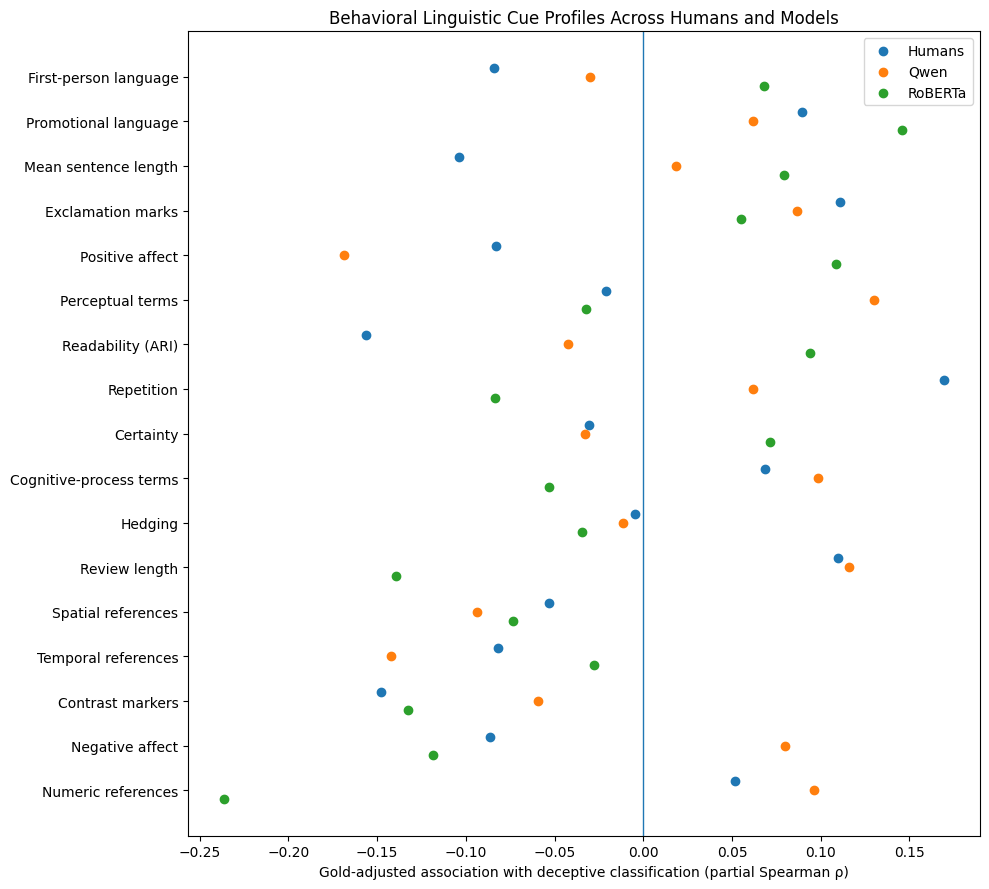

In [ ]:
plot_df = (
    system_comparison_df
    .copy()
)


plot_df[
    "label"
] = (
    plot_df[
        "feature"
    ]
    .map(
        PLOT_LABELS
    )
)


plot_df = (
    plot_df
    .sort_values(
        "Corpus"
    )
    .reset_index(
        drop=True
    )
)


y = np.arange(
    len(
        plot_df
    )
)


fig, ax = plt.subplots(
    figsize=(10, 9)
)


offset = 0.20


ax.scatter(
    plot_df[
        "Humans"
    ],
    y + offset,
    label="Humans"
)


ax.scatter(
    plot_df[
        "Qwen"
    ],
    y,
    label="Qwen"
)


ax.scatter(
    plot_df[
        "RoBERTa"
    ],
    y - offset,
    label="RoBERTa"
)


ax.axvline(
    0,
    linewidth=1
)


ax.set_yticks(
    y
)


ax.set_yticklabels(
    plot_df[
        "label"
    ]
)


ax.set_xlabel(
    "Gold-adjusted association with deceptive classification (partial Spearman ρ)"
)


ax.set_title(
    "Behavioral Linguistic Cue Profiles Across Humans and Models"
)


ax.legend()


fig.tight_layout()


fig.savefig(
    FIGURES_DIR /
    "human_qwen_roberta_cue_profiles.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
system_cue_results_df.to_csv(
    RESULTS_DIR /
    "human_qwen_roberta_linguistic_cue_associations.csv",
    index=False
)


system_comparison_df.to_csv(
    RESULTS_DIR /
    "human_qwen_roberta_cue_comparison.csv",
    index=False
)


direction_alignment_df.to_csv(
    RESULTS_DIR /
    "system_corpus_direction_alignment.csv",
    index=False
)


print(
    "Cue comparison results saved."
)

Cue comparison results saved.


## 36. Corpus Cue Conflict

The final analysis examines whether classification errors occur disproportionately on reviews whose linguistic profile is atypical for their gold class.

Only linguistic features that showed a corpus-level difference after FDR correction are considered.

For each feature, a review is ranked relative to other reviews with the same gold label. The rank is then oriented so that higher values indicate a feature value lying in the direction typically associated with the opposite class.

The resulting `cue_conflict_score` is the mean of these opposite-direction ranks across corpus-significant linguistic features.

This score is exploratory: it summarizes conflict with corpus-level linguistic regularities and should not be interpreted as a psychological measure of deception.

In [ ]:
SIGNIFICANT_CORPUS_FEATURES = (
    feature_stats_df.loc[
        feature_stats_df[
            "significant_fdr"
        ],
        "feature"
    ]
    .tolist()
)


print(
    "Corpus-significant features:",
    len(
        SIGNIFICANT_CORPUS_FEATURES
    )
)


print(
    SIGNIFICANT_CORPUS_FEATURES
)

Corpus-significant features: 14
['numeric_reference_rate', 'first_person_rate', 'negative_affect_rate', 'contrast_marker_rate', 'promotional_marker_rate', 'temporal_reference_rate', 'mean_sentence_length', 'exclamation_rate', 'positive_affect_rate', 'perceptual_rate', 'readability_ari', 'repetition_rate', 'certainty_rate', 'spatial_reference_rate']


In [ ]:
error_analysis_df = (
    linguistic_features_df[
        [
            "review_id",
            "label"
        ]
        +
        PRIMARY_FEATURES
    ]
    .rename(
        columns={
            "label":
                "gold_label"
        }
    )
    .copy()
)

In [ ]:
for feature in (
    SIGNIFICANT_CORPUS_FEATURES
):

    percentile_column = (
        feature
        +
        "_percentile"
    )


    conflict_column = (
        feature
        +
        "_conflict"
    )


    error_analysis_df[
        percentile_column
    ] = (
        error_analysis_df
        .groupby(
            "gold_label"
        )[
            feature
        ]
        .rank(
            pct=True,
            method="average"
        )
    )


    corpus_delta = (
        feature_stats_df.loc[
            feature_stats_df[
                "feature"
            ] == feature,
            "cliffs_delta"
        ]
        .iloc[0]
    )


    percentile = (
        error_analysis_df[
            percentile_column
        ]
    )


    if corpus_delta > 0:

        # Higher values are normally more deceptive-like

        error_analysis_df[
            conflict_column
        ] = np.where(
            error_analysis_df[
                "gold_label"
            ] == "truthful",
            percentile,
            1 - percentile
        )


    else:

        # Higher values are normally more truthful-like

        error_analysis_df[
            conflict_column
        ] = np.where(
            error_analysis_df[
                "gold_label"
            ] == "truthful",
            1 - percentile,
            percentile
        )

In [ ]:
CONFLICT_COLUMNS = [
    feature
    +
    "_conflict"

    for feature
    in SIGNIFICANT_CORPUS_FEATURES
]


error_analysis_df[
    "cue_conflict_score"
] = (
    error_analysis_df[
        CONFLICT_COLUMNS
    ]
    .mean(
        axis=1
    )
)


error_analysis_df[
    "n_strong_conflicts"
] = (
    error_analysis_df[
        CONFLICT_COLUMNS
    ]
    .ge(
        0.85
    )
    .sum(
        axis=1
    )
)


display(
    error_analysis_df[
        [
            "review_id",
            "gold_label",
            "cue_conflict_score",
            "n_strong_conflicts"
        ]
    ]
    .describe()
    .round(3)
)

,cue_conflict_score,n_strong_conflicts
count,800.000,800.000
mean,0.500,1.699
std,0.081,1.316
min,0.245,0.000
25%,0.443,1.000
50%,0.503,1.000
75%,0.556,2.000
max,0.724,7.000


In [ ]:
human_error_df = (
    human_long_df
    .assign(
        correct_judgment=(
            human_long_df[
                "prediction"
            ]
            ==
            human_long_df[
                "gold_label"
            ]
        ).astype(int)
    )
    .groupby(
        "review_id"
    )
    .agg(
        human_accuracy=(
            "correct_judgment",
            "mean"
        )
    )
    .reset_index()
)

In [ ]:
error_analysis_df = (
    error_analysis_df
    .merge(
        qwen_df[
            [
                "review_id",
                "prediction",
                "correct",
                "deception_score"
            ]
        ]
        .rename(
            columns={
                "prediction":
                    "qwen_prediction",

                "correct":
                    "qwen_correct",

                "deception_score":
                    "qwen_deception_score"
            }
        ),
        on="review_id",
        how="left"
    )
    .merge(
        roberta_df[
            [
                "review_id",
                "prediction",
                "correct",
                "p_deceptive"
            ]
        ]
        .rename(
            columns={
                "prediction":
                    "roberta_prediction",

                "correct":
                    "roberta_correct",

                "p_deceptive":
                    "roberta_p_deceptive"
            }
        ),
        on="review_id",
        how="left"
    )
    .merge(
        human_error_df,
        on="review_id",
        how="left"
    )
)

In [ ]:
print(
    "Qwen errors:",
    (
        ~error_analysis_df[
            "qwen_correct"
        ]
    ).sum()
)


print(
    "RoBERTa errors:",
    (
        ~error_analysis_df[
            "roberta_correct"
        ]
    ).sum()
)


print(
    "Reviews with human judgments:",
    error_analysis_df[
        "human_accuracy"
    ].notna().sum()
)

Qwen errors: 352
RoBERTa errors: 50
Reviews with human judgments: 120


## 37. Cue Conflict and Classification Difficulty

The exploratory cue-conflict score is compared with model correctness and human item-level accuracy.

For Qwen and RoBERTa, cue-conflict distributions are compared between correctly and incorrectly classified reviews.

For humans, Spearman correlation is used because review-level human accuracy preserves variation in item difficulty and disagreement across participants.

In [ ]:
error_conflict_rows = []


for system, correct_column in [
    (
        "Qwen",
        "qwen_correct"
    ),
    (
        "RoBERTa",
        "roberta_correct"
    )
]:

    correct_values = (
        error_analysis_df.loc[
            error_analysis_df[
                correct_column
            ],
            "cue_conflict_score"
        ]
        .values
    )


    error_values = (
        error_analysis_df.loc[
            ~error_analysis_df[
                correct_column
            ],
            "cue_conflict_score"
        ]
        .values
    )


    u_statistic, p_value = (
        mannwhitneyu(
            error_values,
            correct_values,
            alternative="two-sided"
        )
    )


    cliffs_delta = (
        2
        *
        u_statistic
        /
        (
            len(
                error_values
            )
            *
            len(
                correct_values
            )
        )
        -
        1
    )


    error_conflict_rows.append(
        {
            "system":
                system,

            "mean_correct":
                correct_values.mean(),

            "mean_error":
                error_values.mean(),

            "median_correct":
                np.median(
                    correct_values
                ),

            "median_error":
                np.median(
                    error_values
                ),

            "cliffs_delta_error_vs_correct":
                cliffs_delta,

            "p_value":
                p_value
        }
    )


error_conflict_df = pd.DataFrame(
    error_conflict_rows
)


display(
    error_conflict_df.round(4)
)

,system,mean_correct,mean_error,median_correct,median_error,cliffs_delta_error_vs_correct,p_value
0,Qwen,0.4951,0.5062,0.4955,0.5133,0.0808,0.0495
1,RoBERTa,0.4951,0.5734,0.4979,0.5708,0.5391,0.0000


In [ ]:
human_conflict_df = (
    error_analysis_df[
        error_analysis_df[
            "human_accuracy"
        ].notna()
    ]
)


human_conflict_rho, human_conflict_p = (
    spearmanr(
        human_conflict_df[
            "cue_conflict_score"
        ],
        human_conflict_df[
            "human_accuracy"
        ]
    )
)


print(
    "Human cue-conflict vs accuracy"
)


print(
    "rho =",
    round(
        human_conflict_rho,
        4
    )
)


print(
    "p =",
    round(
        human_conflict_p,
        4
    )
)

Human cue-conflict vs accuracy
rho = -0.0156
p = 0.8656


## 38. RoBERTa Errors Shared with the Human Evaluation Subset

The ten RoBERTa errors contained in the 120-review human evaluation subset are examined in greater detail.

For each item, the analysis reports human accuracy, Qwen's prediction, RoBERTa's confidence, and the degree to which its linguistic profile conflicts with corpus-level cue directions.

In [ ]:
human_review_ids = set(
    human_review_df[
        "review_id"
    ]
)


roberta_human_errors_df = (
    error_analysis_df[
        (
            error_analysis_df[
                "review_id"
            ].isin(
                human_review_ids
            )
        )
        &
        (
            ~error_analysis_df[
                "roberta_correct"
            ]
        )
    ]
    .copy()
)


print(
    "RoBERTa errors in human subset:",
    len(
        roberta_human_errors_df
    )
)

RoBERTa errors in human subset: 10


In [ ]:
roberta_human_errors_df = (
    roberta_human_errors_df
    .merge(
        human_model_df[
            [
                "review_id",
                "human_prediction"
            ]
        ],
        on="review_id",
        how="left"
    )
)

In [ ]:
display(
    roberta_human_errors_df[
        [
            "review_id",
            "gold_label",
            "human_prediction",
            "human_accuracy",
            "qwen_prediction",
            "roberta_prediction",
            "roberta_p_deceptive",
            "cue_conflict_score",
            "n_strong_conflicts"
        ]
    ]
    .sort_values(
        "cue_conflict_score",
        ascending=False
    )
    .round(3)
)

,review_id,gold_label,human_prediction,human_accuracy,qwen_prediction,roberta_prediction,roberta_p_deceptive,cue_conflict_score,n_strong_conflicts
2,R0242,truthful,tie,0.500,deceptive,deceptive,0.656,0.701,3
1,R0111,truthful,deceptive,0.400,deceptive,deceptive,0.974,0.663,5
8,R0598,deceptive,truthful,0.200,deceptive,truthful,0.338,0.652,6
4,R0304,truthful,deceptive,0.333,deceptive,deceptive,0.999,0.647,2
9,R0671,deceptive,truthful,0.286,deceptive,truthful,0.103,0.632,4
0,R0074,truthful,truthful,0.600,deceptive,deceptive,0.995,0.594,1
5,R0381,truthful,deceptive,0.400,truthful,deceptive,0.997,0.593,2
3,R0296,truthful,truthful,0.800,deceptive,deceptive,0.999,0.592,1
7,R0582,deceptive,truthful,0.400,truthful,truthful,0.001,0.576,5
6,R0524,deceptive,truthful,0.000,truthful,truthful,0.001,0.541,2


In [ ]:
top_conflict_rows = []


for _, row in (
    roberta_human_errors_df.iterrows()
):

    feature_conflicts = []


    for feature in (
        SIGNIFICANT_CORPUS_FEATURES
    ):

        conflict_value = row[
            feature
            +
            "_conflict"
        ]


        feature_conflicts.append(
            (
                feature,
                conflict_value
            )
        )


    feature_conflicts = sorted(
        feature_conflicts,
        key=lambda x: x[1],
        reverse=True
    )


    top_three = (
        feature_conflicts[
            :3
        ]
    )


    top_conflict_rows.append(
        {
            "review_id":
                row[
                    "review_id"
                ],

            "gold_label":
                row[
                    "gold_label"
                ],

            "top_conflict_1":
                top_three[
                    0
                ][0],

            "score_1":
                top_three[
                    0
                ][1],

            "top_conflict_2":
                top_three[
                    1
                ][0],

            "score_2":
                top_three[
                    1
                ][1],

            "top_conflict_3":
                top_three[
                    2
                ][0],

            "score_3":
                top_three[
                    2
                ][1]
        }
    )


top_error_cues_df = pd.DataFrame(
    top_conflict_rows
)


display(
    top_error_cues_df.round(3)
)

,review_id,gold_label,top_conflict_1,score_1,top_conflict_2,score_2,top_conflict_3,score_3
0,R0074,truthful,exclamation_rate,0.985,negative_affect_rate,0.816,spatial_reference_rate,0.801
1,R0111,truthful,perceptual_rate,0.911,certainty_rate,0.890,positive_affect_rate,0.878
2,R0242,truthful,perceptual_rate,0.970,certainty_rate,0.945,promotional_marker_rate,0.885
3,R0296,truthful,temporal_reference_rate,0.866,positive_affect_rate,0.835,negative_affect_rate,0.816
4,R0304,truthful,promotional_marker_rate,0.934,temporal_reference_rate,0.866,negative_affect_rate,0.816
5,R0381,truthful,readability_ari,0.952,mean_sentence_length,0.868,positive_affect_rate,0.845
6,R0524,deceptive,contrast_marker_rate,0.930,promotional_marker_rate,0.872,temporal_reference_rate,0.784
7,R0582,deceptive,spatial_reference_rate,0.942,repetition_rate,0.935,mean_sentence_length,0.911
8,R0598,deceptive,mean_sentence_length,0.978,repetition_rate,0.945,contrast_marker_rate,0.932
9,R0671,deceptive,readability_ari,0.938,numeric_reference_rate,0.914,temporal_reference_rate,0.882


In [ ]:
top_conflict_rows = []


for _, row in (
    roberta_human_errors_df.iterrows()
):

    feature_conflicts = []


    for feature in (
        SIGNIFICANT_CORPUS_FEATURES
    ):

        conflict_value = row[
            feature
            +
            "_conflict"
        ]


        feature_conflicts.append(
            (
                feature,
                conflict_value
            )
        )


    feature_conflicts = sorted(
        feature_conflicts,
        key=lambda x: x[1],
        reverse=True
    )


    top_three = (
        feature_conflicts[
            :3
        ]
    )


    top_conflict_rows.append(
        {
            "review_id":
                row[
                    "review_id"
                ],

            "gold_label":
                row[
                    "gold_label"
                ],

            "top_conflict_1":
                top_three[
                    0
                ][0],

            "score_1":
                top_three[
                    0
                ][1],

            "top_conflict_2":
                top_three[
                    1
                ][0],

            "score_2":
                top_three[
                    1
                ][1],

            "top_conflict_3":
                top_three[
                    2
                ][0],

            "score_3":
                top_three[
                    2
                ][1]
        }
    )


top_error_cues_df = pd.DataFrame(
    top_conflict_rows
)


display(
    top_error_cues_df.round(3)
)

,review_id,gold_label,top_conflict_1,score_1,top_conflict_2,score_2,top_conflict_3,score_3
0,R0074,truthful,exclamation_rate,0.985,negative_affect_rate,0.816,spatial_reference_rate,0.801
1,R0111,truthful,perceptual_rate,0.911,certainty_rate,0.890,positive_affect_rate,0.878
2,R0242,truthful,perceptual_rate,0.970,certainty_rate,0.945,promotional_marker_rate,0.885
3,R0296,truthful,temporal_reference_rate,0.866,positive_affect_rate,0.835,negative_affect_rate,0.816
4,R0304,truthful,promotional_marker_rate,0.934,temporal_reference_rate,0.866,negative_affect_rate,0.816
5,R0381,truthful,readability_ari,0.952,mean_sentence_length,0.868,positive_affect_rate,0.845
6,R0524,deceptive,contrast_marker_rate,0.930,promotional_marker_rate,0.872,temporal_reference_rate,0.784
7,R0582,deceptive,spatial_reference_rate,0.942,repetition_rate,0.935,mean_sentence_length,0.911
8,R0598,deceptive,mean_sentence_length,0.978,repetition_rate,0.945,contrast_marker_rate,0.932
9,R0671,deceptive,readability_ari,0.938,numeric_reference_rate,0.914,temporal_reference_rate,0.882


In [ ]:
error_text_df = (
    roberta_human_errors_df[
        [
            "review_id",
            "gold_label",
            "human_prediction",
            "human_accuracy",
            "qwen_prediction",
            "cue_conflict_score"
        ]
    ]
    .merge(
        df_clean[
            [
                "review_id",
                "text"
            ]
        ],
        on="review_id",
        how="left"
    )
    .merge(
        top_error_cues_df[
            [
                "review_id",
                "top_conflict_1",
                "top_conflict_2",
                "top_conflict_3"
            ]
        ],
        on="review_id",
        how="left"
    )
)


for _, row in (
    error_text_df
    .sort_values(
        "cue_conflict_score",
        ascending=False
    )
    .iterrows()
):

    print(
        "=" * 100
    )

    print(
        row[
            "review_id"
        ],
        "| Gold:",
        row[
            "gold_label"
        ],
        "| Human:",
        row[
            "human_prediction"
        ],
        "| Qwen:",
        row[
            "qwen_prediction"
        ]
    )

    print(
        "Human accuracy:",
        round(
            row[
                "human_accuracy"
            ],
            3
        )
    )

    print(
        "Cue conflict:",
        round(
            row[
                "cue_conflict_score"
            ],
            3
        )
    )

    print(
        "Top conflicting cues:",
        row[
            "top_conflict_1"
        ],
        ",",
        row[
            "top_conflict_2"
        ],
        ",",
        row[
            "top_conflict_3"
        ]
    )

    print()

    print(
        row[
            "text"
        ]
    )

    print()

R0242 | Gold: truthful | Human: tie | Qwen: deceptive
Human accuracy: 0.5
Cue conflict: 0.701
Top conflicting cues: perceptual_rate , certainty_rate , promotional_marker_rate

I stayed at the James in June, and I must say, it felt like I was in some ultra-swanky boutqiue hotel. From the uniforms of the staff.. which consists of a small J pin that they wear with nice suits and such, to the wonderful, comfortable beds, the James just makes you feel ultra-relaxed. The gym in the hotel was fantastic for a hotel gym, and the machines were all new and in fantastic condition. I really enjoyed the complimentary Kiehl's products as well as the soft, cushy beds with futons. Location-wise, it's just off Michigan ave, and it's close to all the shops and restaurants. I'd definitely stay here if I'm' ever back in Chicago. 


R0111 | Gold: truthful | Human: deceptive | Qwen: deceptive
Human accuracy: 0.4
Cue conflict: 0.663
Top conflicting cues: perceptual_rate , certainty_rate , positive_affect_rate

In [ ]:
final_conflict_tests_df = pd.DataFrame(
    {
        "system": [
            "Humans",
            "Qwen",
            "RoBERTa"
        ],

        "p_value": [
            human_conflict_p,
            error_conflict_df.loc[
                error_conflict_df[
                    "system"
                ] == "Qwen",
                "p_value"
            ].iloc[0],
            error_conflict_df.loc[
                error_conflict_df[
                    "system"
                ] == "RoBERTa",
                "p_value"
            ].iloc[0]
        ]
    }
)


reject, p_fdr, _, _ = (
    multipletests(
        final_conflict_tests_df[
            "p_value"
        ],
        method="fdr_bh"
    )
)


final_conflict_tests_df[
    "p_fdr"
] = p_fdr


final_conflict_tests_df[
    "significant_fdr"
] = reject


display(
    final_conflict_tests_df.round(4)
)

,system,p_value,p_fdr,significant_fdr
0,Humans,0.8656,0.8656,False
1,Qwen,0.0495,0.0742,False
2,RoBERTa,0.0000,0.0000,True


In [ ]:
case_detail_rows = []


for _, error_row in (
    top_error_cues_df.iterrows()
):

    review_id = (
        error_row[
            "review_id"
        ]
    )


    gold_label = (
        error_row[
            "gold_label"
        ]
    )


    opposite_label = (
        "deceptive"
        if gold_label == "truthful"
        else "truthful"
    )


    review_row = (
        error_analysis_df.loc[
            error_analysis_df[
                "review_id"
            ] == review_id
        ]
        .iloc[0]
    )


    for rank in [
        1,
        2,
        3
    ]:

        feature = (
            error_row[
                f"top_conflict_{rank}"
            ]
        )


        actual_value = (
            review_row[
                feature
            ]
        )


        gold_median = (
            linguistic_features_df.loc[
                linguistic_features_df[
                    "label"
                ] == gold_label,
                feature
            ]
            .median()
        )


        opposite_median = (
            linguistic_features_df.loc[
                linguistic_features_df[
                    "label"
                ] == opposite_label,
                feature
            ]
            .median()
        )


        case_detail_rows.append(
            {
                "review_id":
                    review_id,

                "gold_label":
                    gold_label,

                "feature":
                    feature,

                "conflict_rank":
                    rank,

                "actual_value":
                    actual_value,

                "gold_class_median":
                    gold_median,

                "opposite_class_median":
                    opposite_median,

                "conflict_score":
                    error_row[
                        f"score_{rank}"
                    ]
            }
        )


error_case_detail_df = pd.DataFrame(
    case_detail_rows
)


display(
    error_case_detail_df.round(3)
)

,review_id,gold_label,feature,conflict_rank,actual_value,gold_class_median,opposite_class_median,conflict_score
0,R0074,truthful,exclamation_rate,1,5.195,0.000,0.529,0.985
1,R0074,truthful,negative_affect_rate,2,0.000,0.847,0.000,0.816
2,R0074,truthful,spatial_reference_rate,3,0.000,0.735,0.527,0.801
3,R0111,truthful,perceptual_rate,1,1.235,0.000,0.000,0.911
4,R0111,truthful,certainty_rate,2,1.235,0.000,0.000,0.890
5,R0111,truthful,positive_affect_rate,3,12.346,8.000,8.824,0.878
6,R0242,truthful,perceptual_rate,1,1.681,0.000,0.000,0.970
7,R0242,truthful,certainty_rate,2,1.681,0.000,0.000,0.945
8,R0242,truthful,promotional_marker_rate,3,2.521,0.761,1.197,0.885
9,R0296,truthful,temporal_reference_rate,1,0.000,1.212,0.926,0.866


In [ ]:
error_conflict_df.to_csv(
    RESULTS_DIR /
    "cue_conflict_model_errors.csv",
    index=False
)


final_conflict_tests_df.to_csv(
    RESULTS_DIR /
    "cue_conflict_fdr_tests.csv",
    index=False
)


roberta_human_errors_df.to_csv(
    RESULTS_DIR /
    "roberta_human_subset_error_analysis.csv",
    index=False
)


error_case_detail_df.to_csv(
    RESULTS_DIR /
    "roberta_error_top_conflicting_cues.csv",
    index=False
)


print(
    "Final error-analysis results saved."
)

Final error-analysis results saved.
